In [1]:
import requests
import pandas as pd
from io import StringIO




In [2]:
url = "https://www.howstat.com/Cricket/Statistics/IPL/MatchList.asp"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}



In [3]:
response = requests.get(url, headers=headers)
response.raise_for_status()  # will raise an error if request failed

print("Status code:", response.status_code)



Status code: 200


In [4]:
# Wrap HTML text in StringIO to avoid the FutureWarning about literal HTML
html_buffer = StringIO(response.text)

tables = pd.read_html(html_buffer)   # this returns a list of DataFrames

print("Number of tables found:", len(tables))
for i, t in enumerate(tables):
    print(f"Table {i}: shape = {t.shape}")



Number of tables found: 5
Table 0: shape = (1, 2)
Table 1: shape = (1, 1)
Table 2: shape = (2, 2)
Table 3: shape = (2, 2)
Table 4: shape = (1182, 7)


In [5]:
# Take the first (and main) table
df = tables[0].copy()





In [6]:

df.head()
            


,0,1
0,NaN,Indian Premier League - Match List Tips for R...


In [7]:
for i, t in enumerate(tables):
    print(i, t.shape)


0 (1, 2)
1 (1, 1)
2 (2, 2)
3 (2, 2)
4 (1182, 7)


In [8]:
df = tables[4].copy()
df.head()


,0,1,2,3,4,5,6
0,Season,Match,Date,Team,Versus,Venue,Result
1,2008,1st,18/04/2008,Kolkata Knight Riders,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Kolkata Knight Riders won by 140 runs
2,2008,2nd,19/04/2008,Chennai Super Kings,Punjab Kings,Punjab Cricket Association IS Bindra Stadium (...,Chennai Super Kings won by 33 runs
3,2008,3rd,19/04/2008,Rajasthan Royals,Delhi Capitals,Arun Jaitley Stadium (Delhi),Delhi Daredevils won by 9 wickets
4,2008,4th,20/04/2008,Deccan Chargers,Kolkata Knight Riders,Eden Gardens (Kolkata),Kolkata Knight Riders won by 5 wickets


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1182 non-null   object
 1   1       1182 non-null   object
 2   2       1182 non-null   object
 3   3       1182 non-null   object
 4   4       1182 non-null   object
 5   5       1182 non-null   object
 6   6       1181 non-null   object
dtypes: object(7)
memory usage: 64.8+ KB


In [10]:
print(df.shape)

(1182, 7)


In [11]:
print(df.columns)

Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')


In [12]:
new_cols = df.iloc[0].tolist()
df = df[1:].reset_index(drop=True)
df.columns = new_cols

In [13]:
print(df.columns)
df.head()

Index(['Season', 'Match', 'Date', 'Team', 'Versus', 'Venue', 'Result'], dtype='object')


,Season,Match,Date,Team,Versus,Venue,Result
0,2008,1st,18/04/2008,Kolkata Knight Riders,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Kolkata Knight Riders won by 140 runs
1,2008,2nd,19/04/2008,Chennai Super Kings,Punjab Kings,Punjab Cricket Association IS Bindra Stadium (...,Chennai Super Kings won by 33 runs
2,2008,3rd,19/04/2008,Rajasthan Royals,Delhi Capitals,Arun Jaitley Stadium (Delhi),Delhi Daredevils won by 9 wickets
3,2008,4th,20/04/2008,Deccan Chargers,Kolkata Knight Riders,Eden Gardens (Kolkata),Kolkata Knight Riders won by 5 wickets
4,2008,5th,20/04/2008,Royal Challengers Bengaluru,Mumbai Indians,Wankhede Stadium (Mumbai),Royal Challengers Bangalore won by 5 wickets


In [14]:
matches = df.copy()
matches.columns = matches.columns.str.strip().str.lower()
print(matches.columns)


Index(['season', 'match', 'date', 'team', 'versus', 'venue', 'result'], dtype='object')


In [15]:
rename_map = {
    "match": "match_no",
    "team": "team1",
    "versus": "team2"
}
matches = matches.rename(columns=rename_map)

print(matches.columns)
matches.head()


Index(['season', 'match_no', 'date', 'team1', 'team2', 'venue', 'result'], dtype='object')


,season,match_no,date,team1,team2,venue,result
0,2008,1st,18/04/2008,Kolkata Knight Riders,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Kolkata Knight Riders won by 140 runs
1,2008,2nd,19/04/2008,Chennai Super Kings,Punjab Kings,Punjab Cricket Association IS Bindra Stadium (...,Chennai Super Kings won by 33 runs
2,2008,3rd,19/04/2008,Rajasthan Royals,Delhi Capitals,Arun Jaitley Stadium (Delhi),Delhi Daredevils won by 9 wickets
3,2008,4th,20/04/2008,Deccan Chargers,Kolkata Knight Riders,Eden Gardens (Kolkata),Kolkata Knight Riders won by 5 wickets
4,2008,5th,20/04/2008,Royal Challengers Bengaluru,Mumbai Indians,Wankhede Stadium (Mumbai),Royal Challengers Bangalore won by 5 wickets


In [16]:
# Make sure it's string, strip spaces
matches["season"] = matches["season"].astype(str).str.strip()

# Try to convert to numeric; invalid ones become NaN
matches["season_num"] = pd.to_numeric(matches["season"], errors="coerce")

# See which rows failed (should include "No. of Matches = 1180")
matches[matches["season_num"].isna()].head()



,season,match_no,date,team1,team2,venue,result,season_num
1180,No. of Matches = 1180,No. of Matches = 1180,No. of Matches = 1180,No. of Matches = 1180,No. of Matches = 1180,No. of Matches = 1180,NaN,NaN


In [17]:
# Keep rows where season_num is not NaN
matches = matches[matches["season_num"].notna()].copy()

# Use season_num as the cleaned season column
matches["season"] = matches["season_num"].astype(int)

# Drop the helper column
matches = matches.drop(columns=["season_num"])

matches["season"].unique(), matches.shape


(array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
        2019, 2020, 2021, 2022, 2023, 2024, 2025]),
 (1180, 7))

In [18]:
matches["date"] = pd.to_datetime(
    matches["date"].astype(str).str.strip(),
    dayfirst=True,
    errors="coerce"
)

matches[["season", "date"]].head()
matches.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1180 entries, 0 to 1179
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   season    1180 non-null   int64         
 1   match_no  1180 non-null   object        
 2   date      1180 non-null   datetime64[ns]
 3   team1     1180 non-null   object        
 4   team2     1180 non-null   object        
 5   venue     1180 non-null   object        
 6   result    1180 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 73.8+ KB


In [19]:
for col in matches.select_dtypes(include="object").columns:
    matches[col] = matches[col].str.strip()
matches.head()


,season,match_no,date,team1,team2,venue,result
0,2008,1st,2008-04-18,Kolkata Knight Riders,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Kolkata Knight Riders won by 140 runs
1,2008,2nd,2008-04-19,Chennai Super Kings,Punjab Kings,Punjab Cricket Association IS Bindra Stadium (...,Chennai Super Kings won by 33 runs
2,2008,3rd,2008-04-19,Rajasthan Royals,Delhi Capitals,Arun Jaitley Stadium (Delhi),Delhi Daredevils won by 9 wickets
3,2008,4th,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Eden Gardens (Kolkata),Kolkata Knight Riders won by 5 wickets
4,2008,5th,2008-04-20,Royal Challengers Bengaluru,Mumbai Indians,Wankhede Stadium (Mumbai),Royal Challengers Bangalore won by 5 wickets


In [20]:
import pandas as pd
import re

def parse_result(res):
    if pd.isna(res):
        return pd.Series([pd.NA, pd.NA, pd.NA, pd.NA])
    
    text = str(res).strip()
    lower = text.lower()
    
    # Pattern: "Mumbai Indians won by 41 runs" / "RR won by 5 wickets"
    m = re.match(r'(.+?)\s+won by\s+(\d+)\s+(runs?|wickets?)', text, flags=re.IGNORECASE)
    if m:
        winner = m.group(1).strip()
        margin = int(m.group(2))
        raw_type = m.group(3).lower()
        win_type = "runs" if "run" in raw_type else "wickets"
        return pd.Series([winner, margin, win_type, "normal"])
    
    # Tied matches
    if "tied" in lower:
        # sometimes text like "Match tied" or "Match tied (DC won the super over)" etc.
        return pd.Series([pd.NA, 0, "tie", "tie"])
    
    # No result / abandoned
    if "no result" in lower:
        return pd.Series([pd.NA, pd.NA, "no_result", "no_result"])
    if "abandoned" in lower:
        return pd.Series([pd.NA, pd.NA, "abandoned", "abandoned"])
    
    # Fallback for anything weird
    return pd.Series([pd.NA, pd.NA, pd.NA, "other"])

matches[["winner", "win_margin", "win_type", "result_category"]] = (
    matches["result"].apply(parse_result)
)

matches[["result", "winner", "win_margin", "win_type", "result_category"]].head()


,result,winner,win_margin,win_type,result_category
0,Kolkata Knight Riders won by 140 runs,Kolkata Knight Riders,140,runs,normal
1,Chennai Super Kings won by 33 runs,Chennai Super Kings,33,runs,normal
2,Delhi Daredevils won by 9 wickets,Delhi Daredevils,9,wickets,normal
3,Kolkata Knight Riders won by 5 wickets,Kolkata Knight Riders,5,wickets,normal
4,Royal Challengers Bangalore won by 5 wickets,Royal Challengers Bangalore,5,wickets,normal


In [21]:
# Keep only matches where win_type is "runs" or "wickets"
decisive = matches[matches["win_type"].isin(["runs", "wickets"])].copy()

decisive.shape


(1146, 11)

In [22]:
decisive["win_margin"].isna().sum()


np.int64(0)

In [23]:
# Wins by RUNS
run_wins = decisive[decisive["win_type"] == "runs"].copy()

# Wins by WICKETS
wicket_wins = decisive[decisive["win_type"] == "wickets"].copy()

run_wins.shape, wicket_wins.shape


((531, 11), (615, 11))

In [24]:
import numpy as np

# Mean and Std Dev for run-margin wins
run_mean = run_wins["win_margin"].mean()
run_std  = run_wins["win_margin"].std()

# Compute Z-score for each run-win match
run_wins["z_margin"] = (run_wins["win_margin"] - run_mean) / run_std


In [25]:
# Mean and Std Dev for wicket-margin wins
wkt_mean = wicket_wins["win_margin"].mean()
wkt_std  = wicket_wins["win_margin"].std()

# Compute Z-score for each wicket-win match
wicket_wins["z_margin"] = (wicket_wins["win_margin"] - wkt_mean) / wkt_std


In [26]:
# Put them back together
dominance_df = pd.concat([run_wins, wicket_wins], ignore_index=True)

# Sanity check
dominance_df[["win_type", "win_margin", "z_margin"]].head()


,win_type,win_margin,z_margin
0,runs,140,4.082091
1,runs,33,0.103019
2,runs,6,-0.901046
3,runs,66,1.330209
4,runs,13,-0.640733


In [27]:
dominance_df["z_margin"].describe()


count     1146.000000
unique     111.000000
top         -0.106053
freq       126.000000
Name: z_margin, dtype: float64

In [28]:
dominance_df.sort_values("z_margin").head()     # closest finishes
dominance_df.sort_values("z_margin").tail()     # biggest blowouts


,season,match_no,date,team1,team2,venue,result,winner,win_margin,win_type,result_category,z_margin
162,2013,31st,2013-04-23,Pune Warriors,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Royal Challengers Bangalore won by 130 runs,Royal Challengers Bangalore,130,runs,normal,3.710215
227,2015,40th,2015-05-06,Punjab Kings,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Royal Challengers Bangalore won by 138 runs,Royal Challengers Bangalore,138,runs,normal,4.007715
0,2008,1st,2008-04-18,Kolkata Knight Riders,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Kolkata Knight Riders won by 140 runs,Kolkata Knight Riders,140,runs,normal,4.082091
254,2016,44th,2016-05-14,Gujarat Lions,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Royal Challengers Bangalore won by 144 runs,Royal Challengers Bangalore,144,runs,normal,4.230841
279,2017,45th,2017-05-06,Mumbai Indians,Delhi Capitals,Barabati Stadium (Cuttack),Mumbai Indians won by 146 runs,Mumbai Indians,146,runs,normal,4.305216


In [29]:
def era_weight(season):
    season = int(season)
    if season <= 2014:
        return 0.7
    elif season <= 2018:
        return 1.0
    else:
        return 1.2

dominance_df["era_weight"] = dominance_df["season"].apply(era_weight)


In [30]:
dominance_df[["season", "era_weight"]].head(20)


,season,era_weight
0,2008,0.7
1,2008,0.7
2,2008,0.7
3,2008,0.7
4,2008,0.7
5,2008,0.7
6,2008,0.7
7,2008,0.7
8,2008,0.7
9,2008,0.7


In [31]:
dominance_df["dominance_score"] = dominance_df["z_margin"] * dominance_df["era_weight"]


In [32]:
import re

# Extract city inside parentheses (if present)
dominance_df["city"] = dominance_df["venue"].str.extract(r"\((.*?)\)")

# Stadium name = venue without parentheses
dominance_df["stadium"] = dominance_df["venue"].str.replace(r"\(.*?\)", "", regex=True).str.strip()

dominance_df[["venue", "stadium", "city"]].head()


,venue,stadium,city
0,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",M Chinnaswamy Stadium,"Bengaluru, Bangalore"
1,Punjab Cricket Association IS Bindra Stadium (...,Punjab Cricket Association IS Bindra Stadium,"Mohali, Chandigarh"
2,MA Chidambaram Stadium (Chennai),MA Chidambaram Stadium,Chennai
3,Punjab Cricket Association IS Bindra Stadium (...,Punjab Cricket Association IS Bindra Stadium,"Mohali, Chandigarh"
4,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",M Chinnaswamy Stadium,"Bengaluru, Bangalore"


In [33]:
# Compute venue-level aggregates using dominance_df

venue_stats = dominance_df.groupby("stadium").agg(
    avg_dominance = ("dominance_score", "mean"),
    dominance_variance = ("dominance_score", "var"),
    match_count = ("dominance_score", "count")
).reset_index()


In [34]:
venue_stats.sort_values("avg_dominance").head()   # thriller venues
venue_stats.sort_values("avg_dominance").tail()   # blowout venues


,stadium,avg_dominance,dominance_variance,match_count
5,Buffalo Park,0.29906,0.542261,4
2,Barabati Stadium,0.332209,1.667521,13
23,Newlands,0.457053,0.549198,6
13,Holkar Cricket Stadium,0.478972,0.566339,9
26,Saurashtra Cricket Association Stadium,0.56252,0.887948,9


In [35]:
import numpy as np

# Add flags to dominance_df
dominance_df["is_thriller"] = dominance_df["z_margin"] < -0.5
dominance_df["is_blowout"] = dominance_df["z_margin"] > 0.5

# Group by stadium and calculate percentages + medians + IQR
comp_stats = dominance_df.groupby("stadium").agg(
    thriller_pct = ("is_thriller", "mean"),
    blowout_pct  = ("is_blowout", "mean"),
    median_dominance = ("dominance_score", "median"),
    dominance_IQR = ("dominance_score", lambda x: np.percentile(x, 75) - np.percentile(x, 25))
).reset_index()


In [36]:
venue_features = venue_stats.merge(comp_stats, on="stadium", how="left")
venue_features.head()


,stadium,avg_dominance,dominance_variance,match_count,thriller_pct,blowout_pct,median_dominance,dominance_IQR
0,Arun Jaitley Stadium,-0.028149,0.898863,93,0.430108,0.236559,-0.127264,1.271870
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,21,0.333333,0.238095,-0.127264,1.299351
2,Barabati Stadium,0.332209,1.667521,13,0.307692,0.307692,-0.074237,0.806971
3,Barsapara Cricket Stadium,-0.12404,1.436668,5,0.600000,0.400000,-0.774103,2.247668
4,Brabourne Stadium,-0.06252,0.759219,26,0.384615,0.230769,-0.202634,1.216728


In [37]:
# Create flags in the match-level dataset
dominance_df["bat_first_win"] = (dominance_df["win_type"] == "runs").astype(int)
dominance_df["chasing_win"]   = (dominance_df["win_type"] == "wickets").astype(int)

# Aggregate at venue level
win_pattern_stats = dominance_df.groupby("stadium").agg(
    bat_first_win_pct = ("bat_first_win", "mean"),
    chasing_win_pct   = ("chasing_win", "mean")
).reset_index()

# Add chasing advantage (difference)
win_pattern_stats["chasing_advantage"] = (
    win_pattern_stats["chasing_win_pct"] - win_pattern_stats["bat_first_win_pct"]
)


In [38]:
venue_features = venue_features.merge(win_pattern_stats, on="stadium", how="left")
venue_features.head()


,stadium,avg_dominance,dominance_variance,match_count,thriller_pct,blowout_pct,median_dominance,dominance_IQR,bat_first_win_pct,chasing_win_pct,chasing_advantage
0,Arun Jaitley Stadium,-0.028149,0.898863,93,0.430108,0.236559,-0.127264,1.271870,0.494624,0.505376,0.010753
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,21,0.333333,0.238095,-0.127264,1.299351,0.428571,0.571429,0.142857
2,Barabati Stadium,0.332209,1.667521,13,0.307692,0.307692,-0.074237,0.806971,0.384615,0.615385,0.230769
3,Barsapara Cricket Stadium,-0.12404,1.436668,5,0.600000,0.400000,-0.774103,2.247668,0.600000,0.400000,-0.200000
4,Brabourne Stadium,-0.06252,0.759219,26,0.384615,0.230769,-0.202634,1.216728,0.538462,0.461538,-0.076923


In [39]:
# Select features for clustering
feature_cols = [
    "avg_dominance",
    "dominance_variance",
    "thriller_pct",
    "blowout_pct",
    "bat_first_win_pct",
    "chasing_win_pct",
    # we skip chasing_advantage because it's derivable from the two above
]

# Extract ML-ready matrix
venue_matrix = venue_features[["stadium"] + feature_cols].copy()

venue_matrix.head()


,stadium,avg_dominance,dominance_variance,thriller_pct,blowout_pct,bat_first_win_pct,chasing_win_pct
0,Arun Jaitley Stadium,-0.028149,0.898863,0.430108,0.236559,0.494624,0.505376
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,0.333333,0.238095,0.428571,0.571429
2,Barabati Stadium,0.332209,1.667521,0.307692,0.307692,0.384615,0.615385
3,Barsapara Cricket Stadium,-0.12404,1.436668,0.600000,0.400000,0.600000,0.400000
4,Brabourne Stadium,-0.06252,0.759219,0.384615,0.230769,0.538462,0.461538


In [40]:
venue_matrix.isna().sum()


stadium               0
avg_dominance         0
dominance_variance    0
thriller_pct          0
blowout_pct           0
bat_first_win_pct     0
chasing_win_pct       0
dtype: int64

In [41]:
from sklearn.preprocessing import StandardScaler

# Select the numeric feature columns (same as earlier)
feature_cols = [
    "avg_dominance",
    "dominance_variance",
    "thriller_pct",
    "blowout_pct",
    "bat_first_win_pct",
    "chasing_win_pct"
]

# Scaler object
scaler = StandardScaler()

# Fit + transform
scaled_values = scaler.fit_transform(venue_matrix[feature_cols])

# Create a scaled dataframe
scaled_df = pd.DataFrame(
    scaled_values,
    columns=feature_cols,
    index=venue_matrix.index
)

scaled_df.head()


,avg_dominance,dominance_variance,thriller_pct,blowout_pct,bat_first_win_pct,chasing_win_pct
0,-0.075191,-0.028445,0.487641,0.004879,0.274118,-0.274118
1,-0.251014,0.928676,-0.084139,0.018094,-0.172364,0.172364
2,1.309122,1.359911,-0.235636,0.616820,-0.469486,0.469486
3,-0.443557,0.942943,1.491431,1.410920,0.986413,-0.986413
4,-0.207226,-0.280671,0.218856,-0.044930,0.570442,-0.570442


In [42]:
scaled_df.mean()


avg_dominance         6.167906e-18
dominance_variance    1.703884e-16
thriller_pct          3.777842e-16
blowout_pct           2.498002e-16
bat_first_win_pct     3.394276e-16
chasing_win_pct       3.856869e-16
dtype: float64

In [43]:
scaled_df.std()


avg_dominance         1.014185
dominance_variance    1.014185
thriller_pct          1.014185
blowout_pct           1.014185
bat_first_win_pct     1.014185
chasing_win_pct       1.014185
dtype: float64

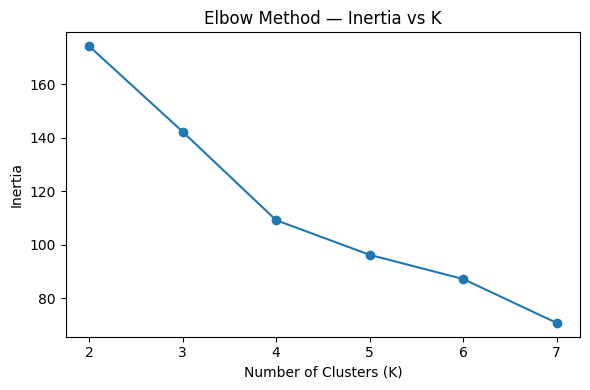

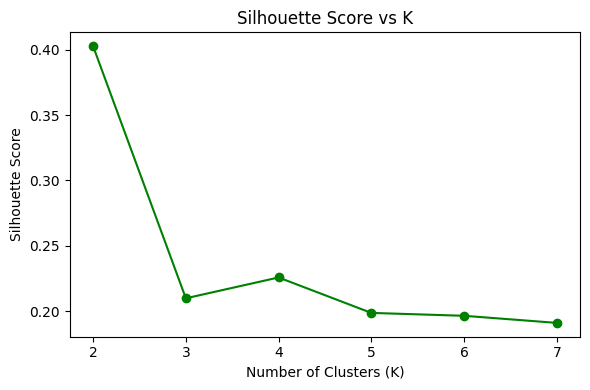

[0.40271299116746934,
 0.20987647883119767,
 0.22581035038069663,
 0.19870697557042344,
 0.19648931421255156,
 0.1910691524439908]

In [236]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K_range = range(2, 8)   # typically 2–6 clusters is sensible

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    
    inertias.append(kmeans.inertia_)
    
    # compute silhouette score
    labels = kmeans.labels_
    sil = silhouette_score(scaled_df, labels)
    sil_scores.append(sil)

# Plot inertia (Elbow plot)
plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method — Inertia vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("Figure2_Elbow.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("Figure3_Silhouette.png", dpi=600, bbox_inches="tight")
plt.show()

sil_scores


In [45]:
from sklearn.cluster import KMeans

# Run KMeans with K=2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_df)

# Get cluster labels
venue_matrix["cluster"] = kmeans.labels_

venue_matrix.head()


,stadium,avg_dominance,dominance_variance,thriller_pct,blowout_pct,bat_first_win_pct,chasing_win_pct,cluster
0,Arun Jaitley Stadium,-0.028149,0.898863,0.430108,0.236559,0.494624,0.505376,1
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,0.333333,0.238095,0.428571,0.571429,1
2,Barabati Stadium,0.332209,1.667521,0.307692,0.307692,0.384615,0.615385,1
3,Barsapara Cricket Stadium,-0.12404,1.436668,0.600000,0.400000,0.600000,0.400000,1
4,Brabourne Stadium,-0.06252,0.759219,0.384615,0.230769,0.538462,0.461538,1


In [46]:
# Merge cluster labels with full venue features
venue_clustered = venue_features.merge(
    venue_matrix[["stadium", "cluster"]],
    on="stadium",
    how="left"
)

venue_clustered.head()


,stadium,avg_dominance,dominance_variance,match_count,thriller_pct,blowout_pct,median_dominance,dominance_IQR,bat_first_win_pct,chasing_win_pct,chasing_advantage,cluster
0,Arun Jaitley Stadium,-0.028149,0.898863,93,0.430108,0.236559,-0.127264,1.271870,0.494624,0.505376,0.010753,1
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,21,0.333333,0.238095,-0.127264,1.299351,0.428571,0.571429,0.142857,1
2,Barabati Stadium,0.332209,1.667521,13,0.307692,0.307692,-0.074237,0.806971,0.384615,0.615385,0.230769,1
3,Barsapara Cricket Stadium,-0.12404,1.436668,5,0.600000,0.400000,-0.774103,2.247668,0.600000,0.400000,-0.200000,1
4,Brabourne Stadium,-0.06252,0.759219,26,0.384615,0.230769,-0.202634,1.216728,0.538462,0.461538,-0.076923,1


In [47]:
venue_clustered.groupby("cluster")[
    ["avg_dominance", "thriller_pct", "blowout_pct", "dominance_variance"]
].mean()


,avg_dominance,thriller_pct,blowout_pct,dominance_variance
cluster,,,,
0,0.221974,0.083333,0.342593,1.098157
1,-0.029535,0.371596,0.226301,0.897925


In [48]:
cluster_summary = venue_clustered.groupby("cluster")[
    ["avg_dominance", "thriller_pct", "blowout_pct", "dominance_variance",
     "bat_first_win_pct", "chasing_win_pct"]
].mean()

cluster_summary


,avg_dominance,thriller_pct,blowout_pct,dominance_variance,bat_first_win_pct,chasing_win_pct
cluster,,,,,,
0,0.221974,0.083333,0.342593,1.098157,0.148148,0.851852
1,-0.029535,0.371596,0.226301,0.897925,0.481882,0.518118


In [49]:
# Identify which cluster is predictable vs chaotic
if cluster_summary.loc[0, "avg_dominance"] > cluster_summary.loc[1, "avg_dominance"]:
    predictable_cluster = 0
    chaotic_cluster = 1
else:
    predictable_cluster = 1
    chaotic_cluster = 0

venue_clustered["cluster_label"] = venue_clustered["cluster"].map({
    predictable_cluster: "Predictable / One-Sided Venue",
    chaotic_cluster: "Chaotic / Thriller Venue"
})


In [50]:
venue_clustered[
    venue_clustered["cluster_label"] == "Predictable / One-Sided Venue"
][["stadium", "avg_dominance", "blowout_pct", "match_count"]]


,stadium,avg_dominance,blowout_pct,match_count
11,Green Park,-0.375569,0.250000,4
13,Holkar Cricket Stadium,0.478972,0.444444,9
26,Saurashtra Cricket Association Stadium,0.56252,0.333333,9


In [51]:
venue_clustered[
    venue_clustered["cluster_label"] == "Chaotic / Thriller Venue"
][["stadium", "thriller_pct", "dominance_variance", "match_count"]]


,stadium,thriller_pct,dominance_variance,match_count
0,Arun Jaitley Stadium,0.430108,0.898863,93
1,BRSABV Ekana Cricket Stadium,0.333333,1.428769,21
2,Barabati Stadium,0.307692,1.667521,13
3,Barsapara Cricket Stadium,0.600000,1.436668,5
4,Brabourne Stadium,0.384615,0.759219,26
5,Buffalo Park,0.250000,0.542261,4
6,Diamond Oval,0.333333,0.933009,3
7,Dr DY Patil Sports Academy,0.297297,0.998096,37
8,Dr YS Rajasekhara Reddy Cricket Stadium,0.411765,2.71308,17
9,Dubai International Cricket Stadium,0.372093,1.285821,43


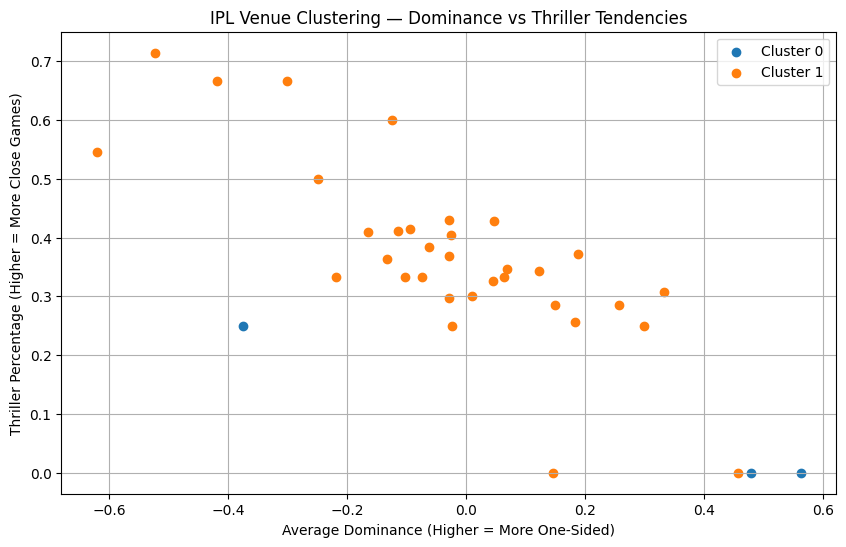

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for label, df_sub in venue_clustered.groupby("cluster"):
    plt.scatter(df_sub["avg_dominance"], df_sub["thriller_pct"], label=f"Cluster {label}")

plt.xlabel("Average Dominance (Higher = More One-Sided)")
plt.ylabel("Thriller Percentage (Higher = More Close Games)")
plt.title("IPL Venue Clustering — Dominance vs Thriller Tendencies")
plt.legend()
plt.grid(True)
plt.show()


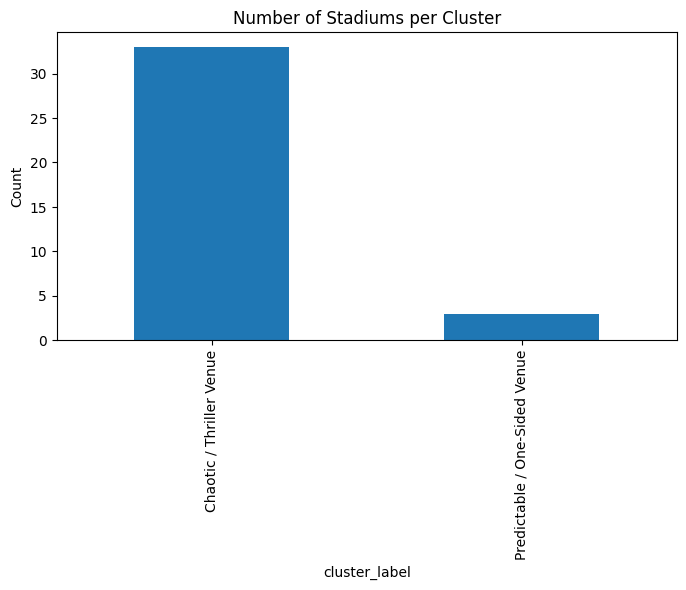

In [53]:
venue_clustered["cluster_label"].value_counts().plot(kind="bar", figsize=(8,4))
plt.title("Number of Stadiums per Cluster")
plt.ylabel("Count")
plt.show()


In [54]:
venue_clustered[["stadium", "cluster_label"]].sort_values("cluster_label")



,stadium,cluster_label
0,Arun Jaitley Stadium,Chaotic / Thriller Venue
19,Maharashtra Cricket Association Stadium,Chaotic / Thriller Venue
20,Mangaung Oval,Chaotic / Thriller Venue
21,Narendra Modi Stadium,Chaotic / Thriller Venue
22,Nehru Stadium,Chaotic / Thriller Venue
23,Newlands,Chaotic / Thriller Venue
24,Punjab Cricket Association IS Bindra Stadium,Chaotic / Thriller Venue
18,Maharaja Yadavindra Singh International Cricke...,Chaotic / Thriller Venue
25,Rajiv Gandhi International Stadium,Chaotic / Thriller Venue
28,Shaheed Veer Narayan Sing International Stadium,Chaotic / Thriller Venue


In [55]:
# CELL 1: Split venues based on match_count

MIN_MATCHES = 10  # you can change this to 8 or 15 later if you want

frequent_venues = venue_features[venue_features["match_count"] >= MIN_MATCHES].copy()
rare_venues      = venue_features[venue_features["match_count"] < MIN_MATCHES].copy()

print("Frequent venues:", frequent_venues.shape[0])
print("Rare venues    :", rare_venues.shape[0])

frequent_venues[["stadium", "match_count"]].sort_values("match_count").head()


Frequent venues: 22
Rare venues    : 14


,stadium,match_count
18,Maharaja Yadavindra Singh International Cricke...,11
32,SuperSport Park,11
2,Barabati Stadium,13
12,Himachal Pradesh Cricket Association Stadium,14
15,Kingsmead,15


In [56]:
from sklearn.preprocessing import StandardScaler

# CELL 2: Build feature matrix & scale ONLY for frequent venues

feature_cols = [
    "avg_dominance",
    "dominance_variance",
    "thriller_pct",
    "blowout_pct",
    "bat_first_win_pct",
    "chasing_win_pct"
]

venue_matrix_freq = frequent_venues[["stadium"] + feature_cols].copy()

scaler_freq = StandardScaler()
scaled_freq_values = scaler_freq.fit_transform(venue_matrix_freq[feature_cols])

scaled_freq_df = pd.DataFrame(
    scaled_freq_values,
    columns=feature_cols,
    index=venue_matrix_freq.index
)

scaled_freq_df.head()


,avg_dominance,dominance_variance,thriller_pct,blowout_pct,bat_first_win_pct,chasing_win_pct
0,-0.035549,-0.375081,0.584522,-0.122803,0.279996,-0.279996
1,-0.279474,0.673070,-0.513821,-0.098331,-0.504114,0.504114
2,1.884956,1.145320,-0.804835,1.010430,-1.025918,1.025918
4,-0.218726,-0.651296,0.068207,-0.215042,0.800398,-0.800398
7,-0.044020,-0.178798,-0.922814,-0.016317,-0.137440,0.137440


In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# CELL 3: KMeans on frequent venues ONLY (K=2)

kmeans_freq = KMeans(n_clusters=2, random_state=42)
kmeans_freq.fit(scaled_freq_df)

venue_matrix_freq["cluster"] = kmeans_freq.labels_

# Merge cluster back into frequent_venues full stats
venue_clustered_freq = frequent_venues.merge(
    venue_matrix_freq[["stadium", "cluster"]],
    on="stadium",
    how="left"
)

# See how many venues per cluster now
print(venue_clustered_freq["cluster"].value_counts())
venue_clustered_freq.head()


cluster
1    12
0    10
Name: count, dtype: int64


,stadium,avg_dominance,dominance_variance,match_count,thriller_pct,blowout_pct,median_dominance,dominance_IQR,bat_first_win_pct,chasing_win_pct,chasing_advantage,cluster
0,Arun Jaitley Stadium,-0.028149,0.898863,93,0.430108,0.236559,-0.127264,1.271870,0.494624,0.505376,0.010753,0
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,21,0.333333,0.238095,-0.127264,1.299351,0.428571,0.571429,0.142857,1
2,Barabati Stadium,0.332209,1.667521,13,0.307692,0.307692,-0.074237,0.806971,0.384615,0.615385,0.230769,1
3,Brabourne Stadium,-0.06252,0.759219,26,0.384615,0.230769,-0.202634,1.216728,0.538462,0.461538,-0.076923,0
4,Dr DY Patil Sports Academy,-0.029738,0.998096,37,0.297297,0.243243,-0.074237,1.293677,0.459459,0.540541,0.081081,1


In [58]:
# CELL 4: Summarize clusters for frequent venues

cluster_summary_freq = venue_clustered_freq.groupby("cluster")[
    ["avg_dominance", "thriller_pct", "blowout_pct", "dominance_variance",
     "bat_first_win_pct", "chasing_win_pct"]
].mean()

print(cluster_summary_freq)


        avg_dominance  thriller_pct  blowout_pct dominance_variance  \
cluster                                                               
0           -0.093792      0.408580     0.222290           0.846206   
1            0.038783      0.353627     0.262582           1.290394   

         bat_first_win_pct  chasing_win_pct  
cluster                                      
0                 0.534162         0.465838  
1                 0.418433         0.581567  


In [59]:
# Decide which cluster is predictable vs chaotic based on avg_dominance
if cluster_summary_freq.loc[0, "avg_dominance"] > cluster_summary_freq.loc[1, "avg_dominance"]:
    predictable_cluster = 0
    chaotic_cluster = 1
else:
    predictable_cluster = 1
    chaotic_cluster = 0

venue_clustered_freq["cluster_label"] = venue_clustered_freq["cluster"].map({
    predictable_cluster: "Predictable / One-Sided Venue",
    chaotic_cluster: "Chaotic / Thriller Venue"
})

venue_clustered_freq[["stadium", "cluster_label", "match_count"]].sort_values("cluster_label")


,stadium,cluster_label,match_count
0,Arun Jaitley Stadium,Chaotic / Thriller Venue,93
15,Punjab Cricket Association IS Bindra Stadium,Chaotic / Thriller Venue,60
14,Narendra Modi Stadium,Chaotic / Thriller Venue,43
13,Maharashtra Cricket Association Stadium,Chaotic / Thriller Venue,51
12,Maharaja Yadavindra Singh International Cricke...,Chaotic / Thriller Venue,11
11,MA Chidambaram Stadium,Chaotic / Thriller Venue,89
9,Kingsmead,Chaotic / Thriller Venue,15
8,Himachal Pradesh Cricket Association Stadium,Chaotic / Thriller Venue,14
21,Wankhede Stadium,Chaotic / Thriller Venue,122
3,Brabourne Stadium,Chaotic / Thriller Venue,26


In [60]:
venue_clustered_freq.to_csv("ipl_venue_clusters_freq.csv", index=False)


In [61]:
import os
os.getcwd()


'/Users/kannanvellayan/Desktop/IPL_VENUE'

In [62]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt


In [63]:
%whos



Variable               Type              Data/Info
--------------------------------------------------
KMeans                 ABCMeta           <class 'sklearn.cluster._kmeans.KMeans'>
K_range                range             range(2, 8)
MIN_MATCHES            int               10
StandardScaler         type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StringIO               type              <class '_io.StringIO'>
chaotic_cluster        int               0
cluster_summary        DataFrame                 avg_dominance  th<...>481882         0.518118  
cluster_summary_freq   DataFrame                 avg_dominance  th<...>418433         0.581567  
col                    str               result
comp_stats             DataFrame                                  <...>0.153148       1.188451  
davies_bouldin_score   function          <function davies_bouldin_score at 0x123610af0>
decisive               DataFrame               season         matc<...>n[1146 rows x 11 

In [64]:
df=pd.read_csv("/Users/kannanvellayan/Desktop/IPL_VENUE/ipl_venue_clusters_freq.csv")
df.columns

Index(['stadium', 'avg_dominance', 'dominance_variance', 'match_count',
       'thriller_pct', 'blowout_pct', 'median_dominance', 'dominance_IQR',
       'bat_first_win_pct', 'chasing_win_pct', 'chasing_advantage', 'cluster',
       'cluster_label'],
      dtype='object')

In [65]:
import os
os.listdir("/Users/kannanvellayan/Desktop/IPL_VENUE")


['webscraptry1.ipynb',
 '.DS_Store',
 'requirements.txt',
 'ipl_model_regimeA_pre2022.pkl',
 'ipl_venue_clusters_freq.csv',
 '.ipynb_checkpoints',
 '.git',
 'ipl_model_regimeB_post2022.pkl',
 'features_regimeA.pkl',
 'features_regimeB.pkl',
 'final_engineered_dataset.csv',
 'venue_app.py']

In [66]:
[name for name in globals() if isinstance(globals()[name], pd.DataFrame)]



['t',
 'df',
 '_6',
 '_8',
 '_13',
 'matches',
 '_15',
 '_16',
 '_19',
 '_20',
 'decisive',
 'run_wins',
 'wicket_wins',
 'dominance_df',
 '_26',
 '_28',
 '_30',
 '_32',
 'venue_stats',
 '_34',
 'comp_stats',
 'venue_features',
 '_36',
 'win_pattern_stats',
 '_38',
 'venue_matrix',
 '_39',
 'scaled_df',
 '_41',
 '_45',
 'venue_clustered',
 '_46',
 '_47',
 'cluster_summary',
 '_48',
 '_50',
 '_51',
 'df_sub',
 '_54',
 'frequent_venues',
 'rare_venues',
 '_55',
 'venue_matrix_freq',
 'scaled_freq_df',
 '_56',
 'venue_clustered_freq',
 '_57',
 'cluster_summary_freq',
 '_59']

In [67]:
pd.read_csv("ipl_venue_clusters_freq.csv")

,stadium,avg_dominance,dominance_variance,match_count,thriller_pct,blowout_pct,median_dominance,dominance_IQR,bat_first_win_pct,chasing_win_pct,chasing_advantage,cluster,cluster_label
0,Arun Jaitley Stadium,-0.028149,0.898863,93,0.430108,0.236559,-0.127264,1.271870,0.494624,0.505376,0.010753,0,Chaotic / Thriller Venue
1,BRSABV Ekana Cricket Stadium,-0.073918,1.428769,21,0.333333,0.238095,-0.127264,1.299351,0.428571,0.571429,0.142857,1,Predictable / One-Sided Venue
2,Barabati Stadium,0.332209,1.667521,13,0.307692,0.307692,-0.074237,0.806971,0.384615,0.615385,0.230769,1,Predictable / One-Sided Venue
3,Brabourne Stadium,-0.062520,0.759219,26,0.384615,0.230769,-0.202634,1.216728,0.538462,0.461538,-0.076923,0,Chaotic / Thriller Venue
4,Dr DY Patil Sports Academy,-0.029738,0.998096,37,0.297297,0.243243,-0.074237,1.293677,0.459459,0.540541,0.081081,1,Predictable / One-Sided Venue
5,Dr YS Rajasekhara Reddy Cricket Stadium,-0.114022,2.713080,17,0.411765,0.235294,-0.417608,1.494996,0.529412,0.470588,-0.058824,1,Predictable / One-Sided Venue
6,Dubai International Cricket Stadium,0.187473,1.285821,43,0.372093,0.302326,-0.127264,1.885072,0.488372,0.511628,0.023256,1,Predictable / One-Sided Venue
7,Eden Gardens,-0.094242,1.073507,99,0.414141,0.262626,-0.127264,1.236115,0.444444,0.555556,0.111111,1,Predictable / One-Sided Venue
8,Himachal Pradesh Cricket Association Stadium,0.148887,0.855815,14,0.285714,0.285714,-0.074237,0.825060,0.642857,0.357143,-0.285714,0,Chaotic / Thriller Venue
9,Kingsmead,-0.301380,0.514897,15,0.666667,0.133333,-0.474544,0.525545,0.600000,0.400000,-0.200000,0,Chaotic / Thriller Venue


In [68]:
matches.head()

,season,match_no,date,team1,team2,venue,result,winner,win_margin,win_type,result_category
0,2008,1st,2008-04-18,Kolkata Knight Riders,Royal Challengers Bengaluru,"M Chinnaswamy Stadium (Bengaluru, Bangalore)",Kolkata Knight Riders won by 140 runs,Kolkata Knight Riders,140,runs,normal
1,2008,2nd,2008-04-19,Chennai Super Kings,Punjab Kings,Punjab Cricket Association IS Bindra Stadium (...,Chennai Super Kings won by 33 runs,Chennai Super Kings,33,runs,normal
2,2008,3rd,2008-04-19,Rajasthan Royals,Delhi Capitals,Arun Jaitley Stadium (Delhi),Delhi Daredevils won by 9 wickets,Delhi Daredevils,9,wickets,normal
3,2008,4th,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Eden Gardens (Kolkata),Kolkata Knight Riders won by 5 wickets,Kolkata Knight Riders,5,wickets,normal
4,2008,5th,2008-04-20,Royal Challengers Bengaluru,Mumbai Indians,Wankhede Stadium (Mumbai),Royal Challengers Bangalore won by 5 wickets,Royal Challengers Bangalore,5,wickets,normal


In [69]:
matches['season'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [70]:
df_new = pd.read_csv("/Users/kannanvellayan/Downloads/IPL.csv")

# Basic inspection
print(df_new.shape)
print(df_new.columns)
df_new.head()

/var/folders/g5/pnchkmpd14b16lbx2j6lzvrr0000gn/T/ipykernel_27144/2416468045.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("/Users/kannanvellayan/Downloads/IPL.csv")


(278205, 64)
Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dt

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [71]:
# Ensure date is datetime (just in case)
df_new['date'] = pd.to_datetime(df_new['date'])

# Filter only first innings
first_innings = df_new[df_new['innings'] == 1]

# Aggregate final total per match
match_totals = (
    first_innings
    .groupby(['match_id', 'season', 'year', 'batting_team', 'bowling_team', 'venue'])
    .agg(first_innings_total=('team_runs', 'max'))
    .reset_index()
)

print("Total Matches:", match_totals.shape[0])
match_totals.head()

Total Matches: 1171


,match_id,season,year,batting_team,bowling_team,venue,first_innings_total
0,335982,2007/08,2008,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,222
1,335983,2007/08,2008,Chennai Super Kings,Kings XI Punjab,"Punjab Cricket Association Stadium, Mohali",240
2,335984,2007/08,2008,Rajasthan Royals,Delhi Daredevils,Feroz Shah Kotla,129
3,335985,2007/08,2008,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,165
4,335986,2007/08,2008,Deccan Chargers,Kolkata Knight Riders,Eden Gardens,110


In [72]:
def assign_band(score):
    if score <= 150:
        return "Low"
    elif score <= 185:
        return "Competitive"
    else:
        return "High"

match_totals['score_band'] = match_totals['first_innings_total'].apply(assign_band)

match_totals.head()

,match_id,season,year,batting_team,bowling_team,venue,first_innings_total,score_band
0,335982,2007/08,2008,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,222,High
1,335983,2007/08,2008,Chennai Super Kings,Kings XI Punjab,"Punjab Cricket Association Stadium, Mohali",240,High
2,335984,2007/08,2008,Rajasthan Royals,Delhi Daredevils,Feroz Shah Kotla,129,Low
3,335985,2007/08,2008,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,165,Competitive
4,335986,2007/08,2008,Deccan Chargers,Kolkata Knight Riders,Eden Gardens,110,Low


In [73]:
band_distribution = match_totals['score_band'].value_counts(normalize=True)
print(band_distribution)

score_band
Competitive    0.433817
Low            0.292058
High           0.274125
Name: proportion, dtype: float64


In [74]:
# Filter powerplay overs (1 to 6)
pp_data = df_new[(df_new['innings'] == 1) & (df_new['over'] <= 6)]

# Aggregate powerplay stats per match
pp_agg = (
    pp_data
    .groupby(['match_id'])
    .agg(
        pp_runs=('team_runs', 'max'),
        pp_wickets=('team_wicket', 'max')
    )
    .reset_index()
)

pp_agg.head()

,match_id,pp_runs,pp_wickets
0,335982,68,1
1,335983,62,2
2,335984,44,3
3,335985,54,2
4,335986,45,2


In [75]:
match_totals = match_totals.merge(pp_agg, on='match_id', how='left')

match_totals.head()

,match_id,season,year,batting_team,bowling_team,venue,first_innings_total,score_band,pp_runs,pp_wickets
0,335982,2007/08,2008,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,222,High,68,1
1,335983,2007/08,2008,Chennai Super Kings,Kings XI Punjab,"Punjab Cricket Association Stadium, Mohali",240,High,62,2
2,335984,2007/08,2008,Rajasthan Royals,Delhi Daredevils,Feroz Shah Kotla,129,Low,44,3
3,335985,2007/08,2008,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,165,Competitive,54,2
4,335986,2007/08,2008,Deccan Chargers,Kolkata Knight Riders,Eden Gardens,110,Low,45,2


In [76]:
match_totals[['pp_runs','pp_wickets']].isna().sum()

pp_runs       0
pp_wickets    0
dtype: int64

In [77]:
dates = df_new[['match_id','date']].drop_duplicates()
match_totals = match_totals.merge(dates, on='match_id', how='left')
match_totals = match_totals.sort_values(['batting_team','date'])

In [78]:
window = 20

match_totals['bat_avg_total_20'] = (
    match_totals
    .groupby('batting_team')['first_innings_total']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

match_totals['bat_avg_pp_runs_20'] = (
    match_totals
    .groupby('batting_team')['pp_runs']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

match_totals['bat_avg_pp_wkts_20'] = (
    match_totals
    .groupby('batting_team')['pp_wickets']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

In [79]:
match_totals['bowl_avg_conceded_20'] = (
    match_totals
    .groupby('bowling_team')['first_innings_total']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

match_totals['bowl_avg_pp_conceded_20'] = (
    match_totals
    .groupby('bowling_team')['pp_runs']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

In [80]:
match_totals[['bat_avg_total_20',
              'bat_avg_pp_runs_20',
              'bowl_avg_conceded_20']].isna().sum()

bat_avg_total_20        95
bat_avg_pp_runs_20      95
bowl_avg_conceded_20    95
dtype: int64

In [81]:
model_df = match_totals.dropna(subset=[
    'bat_avg_total_20',
    'bat_avg_pp_runs_20',
    'bowl_avg_conceded_20'
]).copy()

print("Final modeling dataset shape:", model_df.shape)

Final modeling dataset shape: (987, 16)


In [82]:
match_totals.shape

(1171, 16)

In [83]:
model_df.shape

(987, 16)

In [84]:
venue_stats = (
    match_totals
    .groupby('venue')
    .agg(
        venue_avg_total=('first_innings_total','mean'),
        venue_std_total=('first_innings_total','std'),
        venue_high_rate=('score_band', lambda x: (x=="High").mean()),
        venue_low_rate=('score_band', lambda x: (x=="Low").mean())
    )
    .reset_index()
)

venue_stats.head()

,venue,venue_avg_total,venue_std_total,venue_high_rate,venue_low_rate
0,Arun Jaitley Stadium,168.285714,27.813745,0.285714,0.285714
1,"Arun Jaitley Stadium, Delhi",200.347826,36.003294,0.652174,0.043478
2,Barabati Stadium,167.714286,34.543279,0.285714,0.428571
3,"Barsapara Cricket Stadium, Guwahati",174.600000,25.715754,0.400000,0.200000
4,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,175.363636,33.585067,0.363636,0.227273


In [85]:
model_df = model_df.merge(venue_stats, on='venue', how='left')

model_df.head()

,match_id,season,year,batting_team,bowling_team,venue,first_innings_total,score_band,pp_runs,pp_wickets,date,bat_avg_total_20,bat_avg_pp_runs_20,bat_avg_pp_wkts_20,bowl_avg_conceded_20,bowl_avg_pp_conceded_20,venue_avg_total,venue_std_total,venue_high_rate,venue_low_rate
0,501236,2011,2011,Chennai Super Kings,Deccan Chargers,"MA Chidambaram Stadium, Chepauk",165,Competitive,37,1,2011-05-01,160.85,53.95,1.35,153.400000,54.600000,166.020833,29.292719,0.250000,0.333333
1,501266,2011,2011,Chennai Super Kings,Royal Challengers Bangalore,M Chinnaswamy Stadium,128,Low,27,4,2011-05-22,158.85,49.50,1.35,163.000000,57.800000,168.061538,35.886051,0.323077,0.246154
2,501271,2011,2011,Chennai Super Kings,Royal Challengers Bangalore,"MA Chidambaram Stadium, Chepauk",205,High,61,0,2011-05-28,159.45,48.15,1.45,157.166667,52.666667,166.020833,29.292719,0.250000,0.333333
3,548306,2012,2012,Chennai Super Kings,Mumbai Indians,"MA Chidambaram Stadium, Chepauk",112,Low,48,2,2012-04-04,162.40,48.15,1.40,175.400000,49.200000,166.020833,29.292719,0.250000,0.333333
4,548311,2012,2012,Chennai Super Kings,Deccan Chargers,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,193,High,55,2,2012-04-07,159.80,48.50,1.45,155.333333,51.666667,157.461538,27.311827,0.153846,0.461538


In [86]:
model_df.groupby("score_band")[[
    "bat_avg_total_20",
    "bat_avg_pp_runs_20",
    "bowl_avg_conceded_20",
    "venue_avg_total"
]].mean()

,bat_avg_total_20,bat_avg_pp_runs_20,bowl_avg_conceded_20,venue_avg_total
score_band,,,,
Competitive,163.242440,52.097864,165.932137,166.504567
High,168.017543,53.749301,167.257392,174.423161
Low,162.114636,52.020442,166.027225,161.781643


In [87]:
window = 20

match_totals['is_high'] = (match_totals['first_innings_total'] >= 186).astype(int)
match_totals['is_low'] = (match_totals['first_innings_total'] <= 150).astype(int)

match_totals['bat_high_rate_20'] = (
    match_totals
    .groupby('batting_team')['is_high']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

match_totals['bowl_low_enforce_rate_20'] = (
    match_totals
    .groupby('bowling_team')['is_low']
    .transform(lambda x: x.shift(1).rolling(window, min_periods=5).mean())
)

In [88]:
model_df = match_totals.dropna(subset=[
    'bat_avg_total_20',
    'bat_avg_pp_runs_20',
    'bowl_avg_conceded_20',
    'bat_high_rate_20',
    'bowl_low_enforce_rate_20'
]).copy()

model_df = model_df.merge(venue_stats, on='venue', how='left')

In [89]:
model_df.groupby("score_band")[[
    "bat_high_rate_20",
    "bowl_low_enforce_rate_20",
    "venue_high_rate"
]].mean()

,bat_high_rate_20,bowl_low_enforce_rate_20,venue_high_rate
score_band,,,
Competitive,0.236757,0.299175,0.263601
High,0.286207,0.289087,0.371346
Low,0.226642,0.294310,0.221443


In [90]:
death_data = df_new[(df_new['innings'] == 1) & (df_new['over'] >= 16)]

death_agg = (
    death_data
    .groupby('match_id')
    .agg(
        death_runs=('team_runs', 'max')
    )
    .reset_index()
)

match_totals = match_totals.merge(death_agg, on='match_id', how='left')

# Compute death over runs only (subtract runs before 16th over)
pre_death = df_new[(df_new['innings'] == 1) & (df_new['over'] < 16)]
pre_death_agg = (
    pre_death
    .groupby('match_id')
    .agg(pre_death_runs=('team_runs','max'))
    .reset_index()
)

match_totals = match_totals.merge(pre_death_agg, on='match_id', how='left')

match_totals['death_runs_only'] = match_totals['death_runs'] - match_totals['pre_death_runs']

In [91]:
match_totals['bat_avg_death_runs_20'] = (
    match_totals
    .groupby('batting_team')['death_runs_only']
    .transform(lambda x: x.shift(1).rolling(20, min_periods=5).mean())
)

In [92]:
model_df = match_totals.dropna(subset=[
    'bat_avg_total_20',
    'bat_high_rate_20',
    'bat_avg_death_runs_20'
]).copy()

model_df.groupby("score_band")[["bat_avg_death_runs_20"]].mean()

,bat_avg_death_runs_20
score_band,
Competitive,41.464445
High,42.158482
Low,40.913264


In [93]:
model_df['strength_diff'] = (
    model_df['bat_avg_total_20'] -
    model_df['bowl_avg_conceded_20']
)

In [94]:
model_df.columns

Index(['match_id', 'season', 'year', 'batting_team', 'bowling_team', 'venue',
       'first_innings_total', 'score_band', 'pp_runs', 'pp_wickets', 'date',
       'bat_avg_total_20', 'bat_avg_pp_runs_20', 'bat_avg_pp_wkts_20',
       'bowl_avg_conceded_20', 'bowl_avg_pp_conceded_20', 'is_high', 'is_low',
       'bat_high_rate_20', 'bowl_low_enforce_rate_20', 'death_runs',
       'pre_death_runs', 'death_runs_only', 'bat_avg_death_runs_20',
       'strength_diff'],
      dtype='object')

In [95]:
model_df = model_df.merge(venue_stats, on='venue', how='left')

In [96]:
model_df['venue_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['venue_avg_total']
)

In [97]:
model_df.groupby("score_band")[[
    "strength_diff",
    "venue_adjusted_bat"
]].mean()

,strength_diff,venue_adjusted_bat
score_band,,
Competitive,-2.689697,-2.530112
High,0.760150,-5.879647
Low,-3.964746,0.640397


In [98]:
venue_counts = match_totals.groupby('venue').size().reset_index(name='venue_match_count')

In [99]:
MIN_MATCHES = 10

In [100]:
features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat'
]

In [101]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['score_band'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Competitive': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}


In [102]:
# 1️⃣ Make sure season is numeric
model_df['season'] = pd.to_numeric(model_df['season'], errors='coerce')

# 2️⃣ Drop rows where season became NaN (safety)
model_df = model_df.dropna(subset=['season'])

# 3️⃣ Convert to integer
model_df['season'] = model_df['season'].astype(int)

# 4️⃣ Temporal split (last 2 seasons as test)
train_df = model_df[model_df['season'] <= 2022]
test_df  = model_df[model_df['season'] > 2022]

# 5️⃣ Check sizes
print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (724, 31)
Test size: (214, 31)


In [103]:
train_df = train_df.dropna(subset=features)
test_df  = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df['target']

X_test  = test_df[features]
y_test  = test_df['target']

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# ---- Feature list (LOCKED) ----
features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat'
]

# ---- Prepare X and y ----
X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

# ---- Build Pipeline ----
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(multi_class='multinomial', max_iter=1000))
])

# ---- Train ----
pipeline.fit(X_train, y_train)

# ---- Predict ----
y_pred = pipeline.predict(X_test)

# ---- Evaluate ----
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5527638190954773

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.20      0.26        65
           1       0.61      0.86      0.71       104
           2       0.42      0.27      0.33        30

    accuracy                           0.55       199
   macro avg       0.47      0.44      0.43       199
weighted avg       0.51      0.55      0.51       199


Confusion Matrix:

[[13 45  7]
 [11 89  4]
 [10 12  8]]


/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [105]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.39195979899497485

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.65      0.48        65
           1       0.74      0.28      0.41       104
           2       0.14      0.23      0.17        30

    accuracy                           0.39       199
   macro avg       0.42      0.39      0.35       199
weighted avg       0.53      0.39      0.40       199


Confusion Matrix:

[[42  8 15]
 [47 29 28]
 [21  2  7]]


In [106]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.36180904522613067

Classification Report:

              precision    recall  f1-score   support

           0       0.34      0.62      0.44        65
           1       0.55      0.21      0.31       104
           2       0.24      0.33      0.28        30

    accuracy                           0.36       199
   macro avg       0.38      0.39      0.34       199
weighted avg       0.43      0.36      0.34       199


Confusion Matrix:

[[40 13 12]
 [63 22 19]
 [15  5 10]]


In [107]:
# ---- Short-term batting momentum (last 5 matches) ----
match_totals['bat_avg_total_5'] = (
    match_totals
    .groupby('batting_team')['first_innings_total']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=3).mean())
)

In [108]:
# Rebuild model_df including new feature
model_df = match_totals.dropna(subset=[
    'bat_avg_total_20',
    'bat_high_rate_20',
    'bowl_avg_conceded_20',
    'bat_avg_total_5'
]).copy()

# Re-merge venue stats
model_df = model_df.merge(venue_stats, on='venue', how='left')

# Recreate interaction features
model_df['strength_diff'] = (
    model_df['bat_avg_total_20'] -
    model_df['bowl_avg_conceded_20']
)

model_df['venue_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['venue_avg_total']
)

In [109]:
model_df['season'] = pd.to_numeric(model_df['season'], errors='coerce')
model_df = model_df.dropna(subset=['season'])
model_df['season'] = model_df['season'].astype(int)

In [110]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['score_band'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Competitive': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}


In [111]:
train_df = model_df[model_df['season'] <= 2022]
test_df  = model_df[model_df['season'] > 2022]

In [112]:
features = [
    'bat_avg_total_20',
    'bat_avg_total_5',        # NEW
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat'
]

In [113]:
train_df = train_df.dropna(subset=features)
test_df  = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df['target']

X_test  = test_df[features]
y_test  = test_df['target']

In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5477386934673367

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.23      0.29        65
           1       0.61      0.86      0.71       104
           2       0.42      0.17      0.24        30

    accuracy                           0.55       199
   macro avg       0.47      0.42      0.41       199
weighted avg       0.50      0.55      0.50       199


Confusion Matrix:

[[15 45  5]
 [13 89  2]
 [12 13  5]]


In [115]:
model_df.columns

Index(['match_id', 'season', 'year', 'batting_team', 'bowling_team', 'venue',
       'first_innings_total', 'score_band', 'pp_runs', 'pp_wickets', 'date',
       'bat_avg_total_20', 'bat_avg_pp_runs_20', 'bat_avg_pp_wkts_20',
       'bowl_avg_conceded_20', 'bowl_avg_pp_conceded_20', 'is_high', 'is_low',
       'bat_high_rate_20', 'bowl_low_enforce_rate_20', 'death_runs',
       'pre_death_runs', 'death_runs_only', 'bat_avg_death_runs_20',
       'bat_avg_total_5', 'venue_avg_total', 'venue_std_total',
       'venue_high_rate', 'venue_low_rate', 'strength_diff',
       'venue_adjusted_bat', 'target'],
      dtype='object')

In [116]:
df_new.columns

Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='object')

In [117]:
match_info = (
    df_new[['match_id', 'toss_winner', 'toss_decision', 'stage']]
    .drop_duplicates()
)

In [118]:
match_info.shape

(1169, 4)

In [119]:
match_totals = match_totals.merge(
    match_info,
    on='match_id',
    how='left'
)

In [120]:
match_totals[['toss_winner','toss_decision']].head()

,toss_winner,toss_decision
0,Chennai Super Kings,bat
1,Mumbai Indians,field
2,Chennai Super Kings,bat
3,Chennai Super Kings,bat
4,Chennai Super Kings,bat


In [121]:
model_df = match_totals.copy()

In [122]:
model_df['bat_won_toss'] = (
    model_df['batting_team'] == model_df['toss_winner']
).astype(int)

In [123]:
model_df['bat_chose_bat'] = (
    (model_df['bat_won_toss'] == 1) &
    (model_df['toss_decision'] == 'bat')
).astype(int)

In [124]:
model_df['season_avg_total'] = (
    model_df.groupby('season')['first_innings_total']
    .transform('mean')
)

In [125]:
model_df['season_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['season_avg_total']
)

In [126]:
model_df['is_playoff'] = (
    model_df['stage'].isin(['Qualifier 1','Qualifier 2','Eliminator','Final'])
).astype(int)

In [127]:
model_df = match_totals.copy()

In [128]:
match_totals = match_totals.merge(
    venue_stats,
    on='venue',
    how='left'
)

In [129]:
match_totals[['venue_avg_total','venue_high_rate']].head()

,venue_avg_total,venue_high_rate
0,163.285714,0.171429
1,166.020833,0.250000
2,168.061538,0.323077
3,166.020833,0.250000
4,157.680851,0.148936


In [130]:
model_df = match_totals.copy()

model_df['strength_diff'] = (
    model_df['bat_avg_total_20'] -
    model_df['bowl_avg_conceded_20']
)

model_df['venue_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['venue_avg_total']
)

In [131]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['score_band'])

In [132]:
model_df['season'] = pd.to_numeric(model_df['season'], errors='coerce')
model_df = model_df.dropna(subset=['season'])
model_df['season'] = model_df['season'].astype(int)

train_df = model_df[model_df['season'] <= 2022]
test_df  = model_df[model_df['season'] > 2022]

In [133]:
features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat',
    'bat_won_toss',
    'bat_chose_bat',
    'season_adjusted_bat',
    'is_playoff'
]

In [134]:
match_totals.columns

Index(['match_id', 'season', 'year', 'batting_team', 'bowling_team', 'venue',
       'first_innings_total', 'score_band', 'pp_runs', 'pp_wickets', 'date',
       'bat_avg_total_20', 'bat_avg_pp_runs_20', 'bat_avg_pp_wkts_20',
       'bowl_avg_conceded_20', 'bowl_avg_pp_conceded_20', 'is_high', 'is_low',
       'bat_high_rate_20', 'bowl_low_enforce_rate_20', 'death_runs',
       'pre_death_runs', 'death_runs_only', 'bat_avg_death_runs_20',
       'bat_avg_total_5', 'toss_winner', 'toss_decision', 'stage',
       'venue_avg_total', 'venue_std_total', 'venue_high_rate',
       'venue_low_rate'],
      dtype='object')

In [135]:
model_df = match_totals.copy()

In [136]:
model_df['strength_diff'] = (
    model_df['bat_avg_total_20'] -
    model_df['bowl_avg_conceded_20']
)

model_df['venue_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['venue_avg_total']
)

In [137]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['score_band'])

In [138]:
model_df['season'] = pd.to_numeric(model_df['season'], errors='coerce')
model_df = model_df.dropna(subset=['season'])
model_df['season'] = model_df['season'].astype(int)

In [139]:
train_df = model_df[model_df['season'] <= 2022]
test_df  = model_df[model_df['season'] > 2022]

In [140]:
features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat',
    'bat_won_toss',
    'bat_chose_bat',
    'season_adjusted_bat',
    'is_playoff'
]

In [141]:
# Did batting team win toss?
match_totals['bat_won_toss'] = (
    match_totals['batting_team'] == match_totals['toss_winner']
).astype(int)

# Did batting team choose to bat?
match_totals['bat_chose_bat'] = (
    (match_totals['bat_won_toss'] == 1) &
    (match_totals['toss_decision'] == 'bat')
).astype(int)

In [142]:
# Season average total
match_totals['season_avg_total'] = (
    match_totals.groupby('season')['first_innings_total']
    .transform('mean')
)

# Season-adjusted batting strength
match_totals['season_adjusted_bat'] = (
    match_totals['bat_avg_total_20'] -
    match_totals['season_avg_total']
)

In [143]:
match_totals['is_playoff'] = (
    match_totals['stage']
    .isin(['Qualifier 1','Qualifier 2','Eliminator','Final'])
).astype(int)

In [144]:
match_totals[['bat_won_toss','bat_chose_bat','season_adjusted_bat','is_playoff']].head()

,bat_won_toss,bat_chose_bat,season_adjusted_bat,is_playoff
0,1,1,NaN,0
1,0,0,NaN,0
2,1,1,NaN,0
3,1,1,NaN,0
4,1,1,NaN,0


In [145]:
model_df = match_totals.copy()

In [146]:
model_df['strength_diff'] = (
    model_df['bat_avg_total_20'] -
    model_df['bowl_avg_conceded_20']
)

model_df['venue_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['venue_avg_total']
)

In [147]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['score_band'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Competitive': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}


In [148]:
model_df['season'] = pd.to_numeric(model_df['season'], errors='coerce')
model_df = model_df.dropna(subset=['season'])
model_df['season'] = model_df['season'].astype(int)

In [149]:
train_df = model_df[model_df['season'] <= 2022]
test_df  = model_df[model_df['season'] > 2022]

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (774, 40)
Test: (219, 40)


In [150]:
features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat',
    'bat_won_toss',
    'bat_chose_bat',
    'season_adjusted_bat',
    'is_playoff'
]

In [151]:
train_df = train_df.dropna(subset=features)
test_df  = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df['target']

X_test  = test_df[features]
y_test  = test_df['target']

print("Final Train:", X_train.shape)
print("Final Test:", X_test.shape)

Final Train: (666, 10)
Final Test: (199, 10)


In [152]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5276381909547738

Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.02      0.03        65
           1       0.54      1.00      0.70       104
           2       0.00      0.00      0.00        30

    accuracy                           0.53       199
   macro avg       0.25      0.34      0.24       199
weighted avg       0.35      0.53      0.37       199


Confusion Matrix:

[[  1  64   0]
 [  0 104   0]
 [  4  26   0]]


/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [153]:
# Start fresh from match_totals
model_df = match_totals.copy()

# Interaction features
model_df['strength_diff'] = (
    model_df['bat_avg_total_20'] -
    model_df['bowl_avg_conceded_20']
)

model_df['venue_adjusted_bat'] = (
    model_df['bat_avg_total_20'] -
    model_df['venue_avg_total']
)

In [154]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['score_band'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Competitive': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}


In [155]:
model_df['season'] = pd.to_numeric(model_df['season'], errors='coerce')
model_df = model_df.dropna(subset=['season'])
model_df['season'] = model_df['season'].astype(int)

train_df = model_df[model_df['season'] <= 2022]
test_df  = model_df[model_df['season'] > 2022]

In [156]:
train_df = train_df.dropna(subset=features)
test_df  = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df['target']

X_test  = test_df[features]
y_test  = test_df['target']

In [157]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5276381909547738

Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.02      0.03        65
           1       0.54      1.00      0.70       104
           2       0.00      0.00      0.00        30

    accuracy                           0.53       199
   macro avg       0.25      0.34      0.24       199
weighted avg       0.35      0.53      0.37       199


Confusion Matrix:

[[  1  64   0]
 [  0 104   0]
 [  4  26   0]]


/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [158]:
# Start clean from match_totals
base_df = match_totals.copy()

# Keep only required structural columns
base_df = base_df[[
    'match_id',
    'season',
    'score_band',
    'bat_avg_total_20',
    'bat_high_rate_20',
    'bowl_avg_conceded_20',
    'venue_avg_total',
    'venue_high_rate'
]].copy()

In [159]:
base_df['strength_diff'] = (
    base_df['bat_avg_total_20'] -
    base_df['bowl_avg_conceded_20']
)

base_df['venue_adjusted_bat'] = (
    base_df['bat_avg_total_20'] -
    base_df['venue_avg_total']
)

In [160]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
base_df['target'] = le.fit_transform(base_df['score_band'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Competitive': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}


In [161]:
base_df['season'] = pd.to_numeric(base_df['season'], errors='coerce')
base_df = base_df.dropna()
base_df['season'] = base_df['season'].astype(int)

In [162]:
train_df = base_df[base_df['season'] <= 2022]
test_df  = base_df[base_df['season'] > 2022]

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (666, 11)
Test: (199, 11)


In [163]:
features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'venue_avg_total',
    'venue_high_rate',
    'strength_diff',
    'venue_adjusted_bat'
]

X_train = train_df[features]
y_train = train_df['target']

X_test  = test_df[features]
y_test  = test_df['target']

In [164]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5527638190954773

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.20      0.26        65
           1       0.61      0.86      0.71       104
           2       0.42      0.27      0.33        30

    accuracy                           0.55       199
   macro avg       0.47      0.44      0.43       199
weighted avg       0.51      0.55      0.51       199


Confusion Matrix:

[[13 45  7]
 [11 89  4]
 [10 12  8]]


In [165]:
y_prob = pipeline.predict_proba(X_test)

In [166]:
from sklearn.metrics import log_loss

print("Log Loss:", log_loss(y_test, y_prob))

Log Loss: 0.9255557597779531


In [167]:
import numpy as np

brier = np.mean(np.sum((y_prob - np.eye(3)[y_test])**2, axis=1))
print("Brier Score:", brier)

Brier Score: 0.5567972692569322


In [168]:
max_probs = y_prob.max(axis=1)

print("Avg confidence:", max_probs.mean())
print("High confidence cases:", (max_probs > 0.6).mean())

Avg confidence: 0.5402469945261561
High confidence cases: 0.271356783919598


In [169]:
from sklearn.model_selection import train_test_split

X = base_df[features]
y = base_df['target']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipeline.fit(X_train_r, y_train_r)

y_pred_r = pipeline.predict(X_test_r)

print("Random Split Accuracy:", accuracy_score(y_test_r, y_pred_r))

Random Split Accuracy: 0.5069124423963134


In [170]:
import pandas as pd
coefs = pd.Series(
    pipeline.named_steps['model'].coef_[1],  # or inspect all classes
    index=features
)
print(coefs.sort_values())

venue_adjusted_bat   -0.025832
bat_high_rate_20     -0.009672
bat_avg_total_20      0.037162
venue_avg_total       0.057818
strength_diff         0.115415
venue_high_rate       0.549779
dtype: float64


In [171]:
# Majority class baseline
majority_class = test_df['target'].value_counts().idxmax()

majority_pred = [majority_class] * len(y_test)

from sklearn.metrics import accuracy_score, log_loss
import numpy as np

print("Majority Baseline Accuracy:", accuracy_score(y_test, majority_pred))

Majority Baseline Accuracy: 0.5226130653266332


In [172]:
# Random uniform probability baseline
random_probs = np.full((len(y_test), 3), 1/3)

print("Random Baseline Log Loss:", log_loss(y_test, random_probs))

Random Baseline Log Loss: 1.0986122886681096


In [173]:
reduced_features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'strength_diff'
]

In [174]:
X_train_red = train_df[reduced_features]
X_test_red  = test_df[reduced_features]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_red = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_red.fit(X_train_red, y_train)

y_pred_red = pipeline_red.predict(X_test_red)
y_prob_red = pipeline_red.predict_proba(X_test_red)

print("Reduced Accuracy:", accuracy_score(y_test, y_pred_red))
print("Reduced Log Loss:", log_loss(y_test, y_prob_red))

Reduced Accuracy: 0.32663316582914576
Reduced Log Loss: 1.1377223960565577


In [180]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import pandas as pd

results = []

seasons = sorted(base_df['season'].unique())

# start from 3rd season to ensure enough training data
for i in range(3, len(seasons)):
    
    train_seasons = seasons[:i]
    test_season = seasons[i]
    
    train_fold = base_df[base_df['season'].isin(train_seasons)]
    test_fold = base_df[base_df['season'] == test_season]
    
    X_train = train_fold[features]
    y_train = train_fold['target']
    X_test = test_fold[features]
    y_test = test_fold['target']
    
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_prob)
    
    results.append({
        "test_season": test_season,
        "accuracy": acc,
        "log_loss": ll
    })

rolling_results = pd.DataFrame(results)
print(rolling_results)

    test_season  accuracy  log_loss
0          2013  0.420290  0.967721
1          2014  0.474576  1.043378
2          2015  0.500000  1.016129
3          2016  0.571429  0.972895
4          2017  0.425532  1.127000
5          2018  0.372881  1.112389
6          2019  0.452830  1.046497
7          2021  0.490566  1.066880
8          2022  0.508475  1.051926
9          2023  0.500000  1.011948
10         2024  0.534483  0.882696
11         2025  0.605634  0.885473


In [181]:
print("\nMean Accuracy:", rolling_results['accuracy'].mean())
print("Std Accuracy:", rolling_results['accuracy'].std())
print("Mean Log Loss:", rolling_results['log_loss'].mean())
print("Std Log Loss:", rolling_results['log_loss'].std())


Mean Accuracy: 0.48805794438643063
Std Accuracy: 0.06524692761548405
Mean Log Loss: 1.0154111459923867
Std Log Loss: 0.0775648174776961


In [182]:
baseline_results = []

for season in seasons[3:]:
    test_fold = base_df[base_df['season'] == season]
    majority_class = test_fold['target'].value_counts().idxmax()
    baseline_acc = (test_fold['target'] == majority_class).mean()
    
    baseline_results.append({
        "season": season,
        "baseline_acc": baseline_acc
    })

baseline_df = pd.DataFrame(baseline_results)

print("Mean Baseline Accuracy:", baseline_df['baseline_acc'].mean())
print(baseline_df)

Mean Baseline Accuracy: 0.476610406193067
    season  baseline_acc
0     2013      0.463768
1     2014      0.423729
2     2015      0.465517
3     2016      0.404762
4     2017      0.468085
5     2018      0.508475
6     2019      0.547170
7     2021      0.433962
8     2022      0.440678
9     2023      0.485714
10    2024      0.500000
11    2025      0.577465


In [183]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 5, 10, 50]
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        multi_class='multinomial',
        solver='lbfgs'
    ))
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ipl_final/lib/python3.10/site-packages/sklearn/linear_model/_logisti

In [184]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, log_loss
import pandas as pd
import numpy as np

results = []

seasons = sorted(base_df['season'].unique())

for i in range(3, len(seasons)):
    
    train_seasons = seasons[:i]
    test_season = seasons[i]
    
    train_fold = base_df[base_df['season'].isin(train_seasons)]
    test_fold = base_df[base_df['season'] == test_season]
    
    X_train = train_fold[features]
    y_train = train_fold['target']
    X_test = test_fold[features]
    y_test = test_fold['target']
    
    # Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=3000,
            solver='lbfgs'
        ))
    ])
    
    # Hyperparameter tuning for C
    param_grid = {
        'model__C': [0.01, 0.1, 1, 5, 10, 50]
    }
    
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_prob)
    
    results.append({
        "test_season": test_season,
        "accuracy": acc,
        "log_loss": ll,
        "best_C": grid.best_params_['model__C']
    })

rolling_results = pd.DataFrame(results)

print(rolling_results)
print("\nMean Accuracy:", rolling_results['accuracy'].mean())
print("Std Accuracy:", rolling_results['accuracy'].std())
print("Mean Log Loss:", rolling_results['log_loss'].mean())
print("Std Log Loss:", rolling_results['log_loss'].std())

    test_season  accuracy  log_loss  best_C
0          2013  0.478261  0.960641     0.1
1          2014  0.491525  1.041289     0.1
2          2015  0.517241  1.022152     0.1
3          2016  0.571429  0.982007     0.1
4          2017  0.425532  1.126034     0.1
5          2018  0.372881  1.093784     0.1
6          2019  0.452830  1.046497     1.0
7          2021  0.452830  1.058029     0.1
8          2022  0.508475  1.052436    50.0
9          2023  0.500000  1.012804    10.0
10         2024  0.534483  0.882696     1.0
11         2025  0.605634  0.885473     1.0

Mean Accuracy: 0.49259341916050287
Std Accuracy: 0.06314444615817486
Mean Log Loss: 1.013653505990494
Std Log Loss: 0.07497322794411489


In [186]:
import numpy as np
from scipy.stats import chi2

# Using final temporal split
X_train = train_df[features]
y_train = train_df['target']
X_test = test_df[features]
y_test = test_df['target']

# Train tuned logistic
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, solver='lbfgs', C=0.1))
])

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

# Majority baseline
majority_class = y_train.value_counts().idxmax()
baseline_pred = np.full_like(y_test, majority_class)

# Compute b and c
b = np.sum((model_pred == y_test) & (baseline_pred != y_test))
c = np.sum((model_pred != y_test) & (baseline_pred == y_test))

# McNemar statistic with continuity correction
chi_square = (abs(b - c) - 1)**2 / (b + c)

p_value = 1 - chi2.cdf(chi_square, df=1)

print("b (model only correct):", b)
print("c (baseline only correct):", c)
print("McNemar chi-square:", chi_square)
print("p-value:", p_value)

b (model only correct): 92
c (baseline only correct): 51
McNemar chi-square: 11.188811188811188
p-value: 0.0008229205247354265


In [187]:
n_boot = 1000
accuracies = []

for _ in range(n_boot):
    indices = np.random.choice(len(y_test), len(y_test), replace=True)
    sample_y = y_test.iloc[indices]
    sample_pred = model_pred[indices]
    acc = np.mean(sample_y == sample_pred)
    accuracies.append(acc)

ci_lower = np.percentile(accuracies, 2.5)
ci_upper = np.percentile(accuracies, 97.5)

print("Mean Accuracy:", np.mean(accuracies))
print("95% CI:", (ci_lower, ci_upper))

Mean Accuracy: 0.5338844221105528
95% CI: (np.float64(0.46733668341708545), np.float64(0.6080402010050251))


In [192]:
venue_features = [
    'venue_avg_total',
    'venue_high_rate',
    'venue_adjusted_bat'
]

momentum_features = [
    'bat_avg_total_20',
    'bat_high_rate_20',
    'bowl_avg_conceded_20',
    'strength_diff'
]

full_features = venue_features + momentum_features

In [193]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, log_loss
import pandas as pd
import numpy as np

def rolling_validation(feature_list):
    
    results = []
    seasons = sorted(base_df['season'].unique())
    
    for i in range(3, len(seasons)):
        
        train_seasons = seasons[:i]
        test_season = seasons[i]
        
        train_fold = base_df[base_df['season'].isin(train_seasons)]
        test_fold = base_df[base_df['season'] == test_season]
        
        X_train = train_fold[feature_list]
        y_train = train_fold['target']
        X_test = test_fold[feature_list]
        y_test = test_fold['target']
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=3000, solver='lbfgs'))
        ])
        
        param_grid = {
            'model__C': [0.01, 0.1, 1, 5, 10, 50]
        }
        
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        ll = log_loss(y_test, y_prob)
        
        results.append({
            "accuracy": acc,
            "log_loss": ll
        })
    
    df_results = pd.DataFrame(results)
    
    return {
        "mean_accuracy": df_results['accuracy'].mean(),
        "std_accuracy": df_results['accuracy'].std(),
        "mean_log_loss": df_results['log_loss'].mean()
    }

In [194]:
# Full model
full_results = rolling_validation(full_features)

# Remove venue intelligence
no_venue_results = rolling_validation(momentum_features)

# Remove momentum/team features
no_momentum_results = rolling_validation(venue_features)

print("Full Model:", full_results)
print("No Venue Features:", no_venue_results)
print("No Momentum Features:", no_momentum_results)

Full Model: {'mean_accuracy': np.float64(0.4835715726060614), 'std_accuracy': np.float64(0.06356368674212988), 'mean_log_loss': np.float64(1.0136100380389674)}
No Venue Features: {'mean_accuracy': np.float64(0.4122756200679294), 'std_accuracy': np.float64(0.07452795926328273), 'mean_log_loss': np.float64(1.0900939601071031)}
No Momentum Features: {'mean_accuracy': np.float64(0.49201446806808), 'std_accuracy': np.float64(0.07614567950210971), 'mean_log_loss': np.float64(1.0172865591150018)}


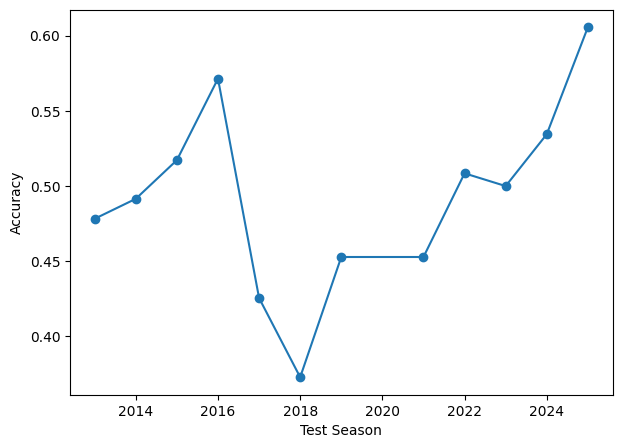

In [246]:
plt.figure(figsize=(7,5))

plt.plot(rolling_results['test_season'],
         rolling_results['accuracy'],
         marker='o')

plt.xlabel("Test Season")
plt.ylabel("Accuracy")

plt.savefig("Figure5_RollingTemporalStability.png",
            dpi=600,
            bbox_inches="tight")

plt.show()

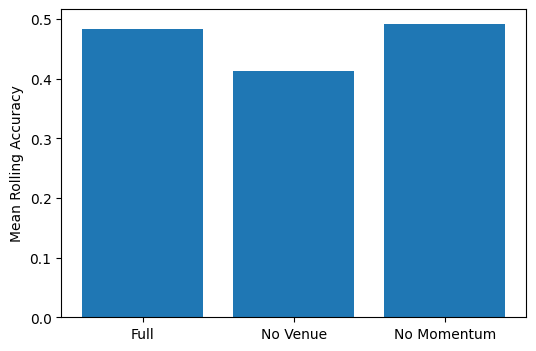

In [247]:
import matplotlib.pyplot as plt

models = ['Full', 'No Venue', 'No Momentum']
accuracies = [
    full_results['mean_accuracy'],
    no_venue_results['mean_accuracy'],
    no_momentum_results['mean_accuracy']
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.ylabel("Mean Rolling Accuracy")

plt.savefig("Figure6_AblationStudy.png",
            dpi=600,
            bbox_inches="tight")

plt.show()

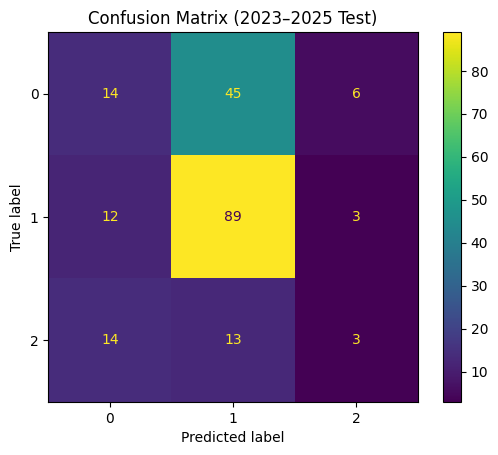

In [199]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, model_pred)
plt.title("Confusion Matrix (2023–2025 Test)")
plt.show()

In [201]:
# Primary split (your deployment scenario)

primary_train = base_df[base_df['season'] <= 2022]
primary_test  = base_df[base_df['season'] > 2022]

X_train_p = primary_train[full_features]
y_train_p = primary_train['target']

X_test_p = primary_test[full_features]
y_test_p = primary_test['target']

In [202]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

primary_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

primary_pipeline.fit(X_train_p, y_train_p)

model_pred_p = primary_pipeline.predict(X_test_p)
y_prob_p = primary_pipeline.predict_proba(X_test_p)

In [203]:
from sklearn.metrics import accuracy_score, log_loss
import numpy as np

primary_accuracy = accuracy_score(y_test_p, model_pred_p)
primary_logloss = log_loss(y_test_p, y_prob_p)

print("Primary Accuracy:", primary_accuracy)
print("Primary Log Loss:", primary_logloss)

Primary Accuracy: 0.5628140703517588
Primary Log Loss: 0.925641278610635


In [204]:
majority_class = y_train_p.value_counts().idxmax()
baseline_pred = np.full_like(y_test_p, majority_class)

baseline_accuracy = accuracy_score(y_test_p, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.32663316582914576


In [205]:
print("Absolute Improvement:", primary_accuracy - baseline_accuracy)

Absolute Improvement: 0.23618090452261303


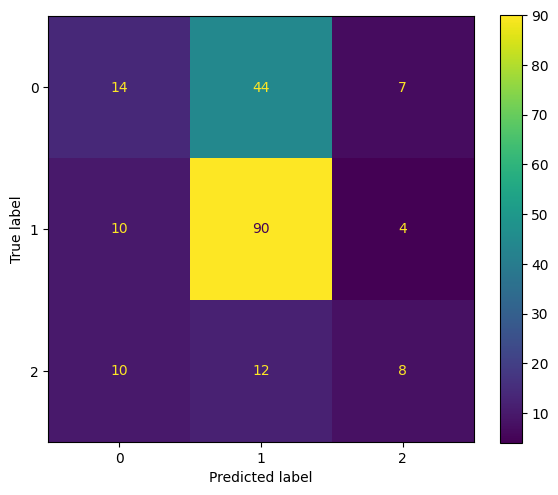

In [244]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test_p,
    model_pred_p,
    ax=ax,
    cmap="viridis"   # optional but cleaner
)

plt.tight_layout()
plt.savefig("Figure4_ConfusionMatrix.png", dpi=600)
plt.show()

In [207]:
from sklearn.metrics import classification_report

print("Classification Report (2023–2025 Deployment Test)\n")
print(classification_report(y_test_p, model_pred_p))

Classification Report (2023–2025 Deployment Test)

              precision    recall  f1-score   support

           0       0.41      0.22      0.28        65
           1       0.62      0.87      0.72       104
           2       0.42      0.27      0.33        30

    accuracy                           0.56       199
   macro avg       0.48      0.45      0.44       199
weighted avg       0.52      0.56      0.52       199



In [208]:
import numpy as np
from sklearn.metrics import accuracy_score

n_boot = 1000
rng = np.random.default_rng(42)
boot_scores = []

for _ in range(n_boot):
    indices = rng.choice(len(y_test_p), size=len(y_test_p), replace=True)
    score = accuracy_score(
        y_test_p.iloc[indices],
        model_pred_p[indices]
    )
    boot_scores.append(score)

mean_acc = np.mean(boot_scores)
lower = np.percentile(boot_scores, 2.5)
upper = np.percentile(boot_scores, 97.5)

print("Mean Accuracy:", mean_acc)
print("95% CI:", (lower, upper))

Mean Accuracy: 0.5637236180904522
95% CI: (np.float64(0.49246231155778897), np.float64(0.6282663316582914))


In [209]:
import numpy as np
from scipy.stats import chi2

# Correct prediction indicators
model_correct = (model_pred_p == y_test_p).astype(int)
baseline_correct = (baseline_pred == y_test_p).astype(int)

# b and c values
b = np.sum((model_correct == 1) & (baseline_correct == 0))  # model only correct
c = np.sum((model_correct == 0) & (baseline_correct == 1))  # baseline only correct

print("Model only correct (b):", b)
print("Baseline only correct (c):", c)

# McNemar statistic with continuity correction
chi_square = (abs(b - c) - 1)**2 / (b + c)

# p-value from chi-square distribution with 1 degree of freedom
p_value = 1 - chi2.cdf(chi_square, df=1)

print("McNemar chi-square:", chi_square)
print("p-value:", p_value)

Model only correct (b): 98
Baseline only correct (c): 51
McNemar chi-square: 14.201342281879194
p-value: 0.0001642533034771354


In [210]:
import pandas as pd
import numpy as np

# Your already computed values
primary_accuracy = primary_accuracy
primary_logloss = primary_logloss
baseline_accuracy = baseline_accuracy
mcnemar_p = p_value
ci_lower, ci_upper = lower, upper

# Random baseline log loss for 3-class classification
random_logloss = -np.log(1/3)

results_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log Loss",
        "Baseline Accuracy",
        "Random Log Loss (3-class)",
        "Absolute Improvement",
        "McNemar p-value",
        "95% CI (Accuracy)"
    ],
    "Value": [
        round(primary_accuracy, 4),
        round(primary_logloss, 4),
        round(baseline_accuracy, 4),
        round(random_logloss, 4),
        round(primary_accuracy - baseline_accuracy, 4),
        round(mcnemar_p, 6),
        f"({round(ci_lower,3)} – {round(ci_upper,3)})"
    ]
})

results_table

,Metric,Value
0,Accuracy,0.5628
1,Log Loss,0.9256
2,Baseline Accuracy,0.3266
3,Random Log Loss (3-class),1.0986
4,Absolute Improvement,0.2362
5,McNemar p-value,0.000164
6,95% CI (Accuracy),(0.492 – 0.628)


In [211]:
import pandas as pd

rolling_summary = pd.DataFrame({
    "Metric": [
        "Mean Accuracy",
        "Std Accuracy",
        "Mean Log Loss",
        "Std Log Loss"
    ],
    "Value": [
        round(rolling_results["accuracy"].mean(), 4),
        round(rolling_results["accuracy"].std(), 4),
        round(rolling_results["log_loss"].mean(), 4),
        round(rolling_results["log_loss"].std(), 4)
    ]
})

rolling_summary

,Metric,Value
0,Mean Accuracy,0.4926
1,Std Accuracy,0.0631
2,Mean Log Loss,1.0137
3,Std Log Loss,0.0750


In [212]:
ablation_summary = pd.DataFrame({
    "Model Variant": [
        "Full Model",
        "No Venue Features",
        "No Momentum Features"
    ],
    "Mean Accuracy": [
        round(full_results["mean_accuracy"], 4),
        round(no_venue_results["mean_accuracy"], 4),
        round(no_momentum_results["mean_accuracy"], 4)
    ]
})

ablation_summary

,Model Variant,Mean Accuracy
0,Full Model,0.4836
1,No Venue Features,0.4123
2,No Momentum Features,0.4920


In [219]:
cluster_features = [
    'avg_dominance',
    'dominance_variance',
    'thriller_pct',
    'blowout_pct',
    'bat_first_win_pct',
    'chasing_win_pct',
    'chasing_advantage'
]

In [216]:
venue_clustered_freq.columns

Index(['stadium', 'avg_dominance', 'dominance_variance', 'match_count',
       'thriller_pct', 'blowout_pct', 'median_dominance', 'dominance_IQR',
       'bat_first_win_pct', 'chasing_win_pct', 'chasing_advantage', 'cluster',
       'cluster_label'],
      dtype='object')

In [220]:
cluster_summary = (
    venue_clustered_freq
    .groupby('cluster_label')[cluster_features]
    .mean()
    .round(3)
)

cluster_summary

,avg_dominance,dominance_variance,thriller_pct,blowout_pct,bat_first_win_pct,chasing_win_pct,chasing_advantage
cluster_label,,,,,,,
Chaotic / Thriller Venue,-0.093792,0.846206,0.409,0.222,0.534,0.466,-0.068
Predictable / One-Sided Venue,0.038783,1.290394,0.354,0.263,0.418,0.582,0.163


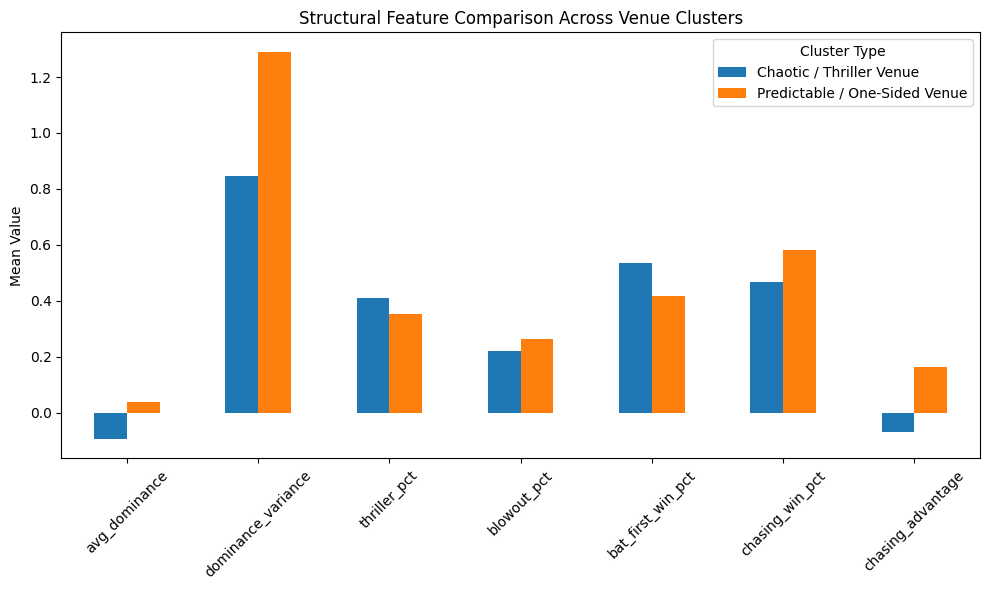

In [221]:
import matplotlib.pyplot as plt

cluster_summary.T.plot(kind='bar', figsize=(10,6))
plt.title("Structural Feature Comparison Across Venue Clusters")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster Type")
plt.tight_layout()
plt.show()

In [222]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 🔹 Define final production pipeline
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# 🔹 Train on FULL dataset
X_full = base_df[full_features]
y_full = base_df['target']

final_pipeline.fit(X_full, y_full)

# 🔹 Save model
joblib.dump(final_pipeline, "ipl_score_band_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [223]:
import joblib

model = joblib.load("ipl_score_band_model.pkl")
print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])


In [224]:
joblib.dump(full_features, "model_features.pkl")

['model_features.pkl']

In [225]:
base_df.columns

Index(['match_id', 'season', 'score_band', 'bat_avg_total_20',
       'bat_high_rate_20', 'bowl_avg_conceded_20', 'venue_avg_total',
       'venue_high_rate', 'strength_diff', 'venue_adjusted_bat', 'target'],
      dtype='object')

In [226]:
venue_master = (
    match_totals.groupby('venue')
    .agg(
        matches=('match_id','count'),
        avg_total=('first_innings_total','mean'),
        high_score_rate=('is_high','mean'),
        low_score_rate=('is_low','mean'),
        recent_avg_total=('first_innings_total', lambda x: x.tail(10).mean())
    )
    .round(2)
    .reset_index()
)

venue_master.to_csv("venue_master_insights.csv", index=False)

venue_master.head()

,venue,matches,avg_total,high_score_rate,low_score_rate,recent_avg_total
0,Arun Jaitley Stadium,14,168.29,0.29,0.29,167.40
1,"Arun Jaitley Stadium, Delhi",23,200.35,0.65,0.04,206.00
2,Barabati Stadium,7,167.71,0.29,0.43,167.71
3,"Barsapara Cricket Stadium, Guwahati",5,174.60,0.40,0.20,174.60
4,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,22,175.36,0.36,0.23,175.30


In [227]:
team_master = (
    match_totals.groupby('batting_team')
    .agg(
        avg_total=('first_innings_total','mean'),
        high_score_rate=('is_high','mean')
    )
    .round(2)
    .reset_index()
)

team_master.to_csv("team_master_insights.csv", index=False)

team_master.head()

,batting_team,avg_total,high_score_rate
0,Chennai Super Kings,170.09,0.32
1,Deccan Chargers,157.33,0.16
2,Delhi Capitals,172.85,0.34
3,Delhi Daredevils,156.21,0.21
4,Gujarat Lions,161.93,0.14


In [228]:
match_totals["venue"].unique()

array(['Punjab Cricket Association Stadium, Mohali',
       'MA Chidambaram Stadium, Chepauk', 'M Chinnaswamy Stadium',
       'Sawai Mansingh Stadium', 'Wankhede Stadium',
       'Dr DY Patil Sports Academy', "St George's Park", 'Kingsmead',
       'SuperSport Park', 'New Wanderers Stadium', 'Buffalo Park',
       'Eden Gardens', 'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha', 'Nehru Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Feroz Shah Kotla', 'Subrata Roy Sahara Stadium',
       'Himachal Pradesh Cricket Association Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'Sheikh Zayed Stadium', 'Dubai International Cricket Stadium',
       'JSCA International Stadium Complex',
       'Sardar Patel Stadium, Motera',
       'Shaheed Veer Narayan Singh International Stadium',
       'Maharashtra Cricket Association Stadium',
       'Rajiv Gandhi International Stadium', 'MA Chidambaram Stadium',
      

In [229]:
venue_mapping = {
    # Delhi
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",

    # Chennai
    "MA Chidambaram Stadium": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",

    # Bengaluru
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",

    # Mumbai
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy",

    # Punjab
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association Stadium, Mohali",

    # Hyderabad
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium, Uppal",

    # Maharashtra Pune
    "Maharashtra Cricket Association Stadium, Pune": "Maharashtra Cricket Association Stadium",

    # Ahmedabad
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium, Ahmedabad",

    # Dharamsala
    "Himachal Pradesh Cricket Association Stadium, Dharamsala": "Himachal Pradesh Cricket Association Stadium",

    # Visakhapatnam
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam":
        "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",

    # Kolkata
    "Eden Gardens, Kolkata": "Eden Gardens",

    # Jaipur
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",

    # Lucknow
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow":
        "Ekana Cricket Stadium, Lucknow",

    # Mohali new
    "Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh":
        "Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur"
}

In [230]:
match_totals['venue'] = match_totals['venue'].replace(venue_mapping)

In [231]:
sorted(match_totals['venue'].unique())

['Arun Jaitley Stadium',
 'Barabati Stadium',
 'Barsapara Cricket Stadium, Guwahati',
 'Brabourne Stadium',
 'Brabourne Stadium, Mumbai',
 'Buffalo Park',
 'De Beers Diamond Oval',
 'Dr DY Patil Sports Academy',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
 'Dubai International Cricket Stadium',
 'Eden Gardens',
 'Ekana Cricket Stadium, Lucknow',
 'Green Park',
 'Himachal Pradesh Cricket Association Stadium',
 'Holkar Cricket Stadium',
 'JSCA International Stadium Complex',
 'Kingsmead',
 'M Chinnaswamy Stadium',
 'MA Chidambaram Stadium',
 'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur',
 'Maharashtra Cricket Association Stadium',
 'Narendra Modi Stadium, Ahmedabad',
 'Nehru Stadium',
 'New Wanderers Stadium',
 'Newlands',
 'OUTsurance Oval',
 'Punjab Cricket Association Stadium, Mohali',
 'Rajiv Gandhi International Stadium, Uppal',
 'Saurashtra Cricket Association Stadium',
 'Sawai Mansingh Stadium',
 'Shaheed Veer Narayan Singh International Stadium'

In [232]:
venue_master = (
    match_totals.groupby('venue')
    .agg(
        matches=('match_id','count'),
        avg_total=('first_innings_total','mean'),
        high_score_rate=('is_high','mean'),
        low_score_rate=('is_low','mean'),
        recent_avg_total=('first_innings_total', lambda x: x.tail(10).mean())
    )
    .round(2)
    .reset_index()
)

venue_master.to_csv("venue_master_insights.csv", index=False)

venue_master.head()

,venue,matches,avg_total,high_score_rate,low_score_rate,recent_avg_total
0,Arun Jaitley Stadium,97,171.77,0.35,0.24,191.60
1,Barabati Stadium,7,167.71,0.29,0.43,167.71
2,"Barsapara Cricket Stadium, Guwahati",5,174.60,0.40,0.20,174.60
3,Brabourne Stadium,10,180.40,0.40,0.00,180.40
4,"Brabourne Stadium, Mumbai",17,177.41,0.41,0.18,168.00


In [233]:
venues_2025 = match_totals[match_totals['season'] == 2025]['venue'].unique()

In [234]:
import joblib
joblib.dump(sorted(venues_2025), "active_venues.pkl")

['active_venues.pkl']

In [235]:
import pandas as pd
import numpy as np
import joblib
from itertools import product

# Load model and files
model = joblib.load("ipl_score_band_model.pkl")
model_features = joblib.load("model_features.pkl")
venue_df = pd.read_csv("venue_master_insights.csv")
team_df = pd.read_csv("team_master_insights.csv")
ACTIVE_VENUES = joblib.load("active_venues.pkl")

ACTIVE_TEAMS = [
    "Chennai Super Kings",
    "Mumbai Indians",
    "Royal Challengers Bengaluru",
    "Kolkata Knight Riders",
    "Sunrisers Hyderabad",
    "Rajasthan Royals",
    "Delhi Capitals",
    "Punjab Kings",
    "Gujarat Titans",
    "Lucknow Super Giants"
]

rows = []

for batting, bowling in product(ACTIVE_TEAMS, ACTIVE_TEAMS):
    if batting == bowling:
        continue
        
    for venue in ACTIVE_VENUES:
        
        team_bat = team_df[team_df['batting_team'] == batting].iloc[0]
        team_bowl = team_df[team_df['batting_team'] == bowling].iloc[0]
        venue_row = venue_df[venue_df['venue'] == venue].iloc[0]
        
        input_dict = {
            "bat_avg_total_20": team_bat["avg_total"],
            "bat_high_rate_20": team_bat["high_score_rate"],
            "bowl_avg_conceded_20": team_bowl["avg_total"],
            "venue_avg_total": venue_row["avg_total"],
            "venue_high_rate": venue_row["high_score_rate"],
            "strength_diff": team_bat["avg_total"] - team_bowl["avg_total"],
            "venue_adjusted_bat": team_bat["avg_total"] - venue_row["avg_total"]
        }
        
        input_df = pd.DataFrame([input_dict])
        input_df = input_df[model_features]
        
        probs = model.predict_proba(input_df)[0]
        
        rows.append([
            batting,
            bowling,
            venue,
            probs[0],
            probs[1],
            probs[2]
        ])

full_sim = pd.DataFrame(rows, columns=[
    "Batting Team",
    "Bowling Team",
    "Venue",
    "P_Low",
    "P_Competitive",
    "P_High"
])

full_sim.to_csv("full_league_simulation.csv", index=False)

In [240]:
scaled_df.columns

Index(['avg_dominance', 'dominance_variance', 'thriller_pct', 'blowout_pct',
       'bat_first_win_pct', 'chasing_win_pct'],
      dtype='object')

In [242]:
%who DataFrame

X	 X_full	 X_test	 X_test_p	 X_test_r	 X_test_red	 X_train	 X_train_p	 X_train_r	 
X_train_red	 ablation_summary	 base_df	 baseline_df	 cluster_summary	 cluster_summary_freq	 comp_stats	 dates	 death_agg	 
death_data	 decisive	 df	 df_new	 df_sub	 dominance_df	 first_innings	 frequent_venues	 full_sim	 
input_df	 match_info	 match_totals	 matches	 model_df	 pp_agg	 pp_data	 pre_death	 pre_death_agg	 
primary_test	 primary_train	 rare_venues	 results_table	 rolling_results	 rolling_summary	 run_wins	 scaled_df	 scaled_freq_df	 
t	 team_df	 team_master	 test_df	 test_fold	 train_df	 train_fold	 venue_clustered	 venue_clustered_freq	 
venue_counts	 venue_df	 venue_master	 venue_matrix	 venue_matrix_freq	 venue_stats	 wicket_wins	 win_pattern_stats	 


In [248]:
y_train_p.value_counts()

target
0    297
2    221
1    148
Name: count, dtype: int64